In [1]:
# librariies
import xarray as xr
import numpy as np
import pandas as pd

from snobedo.snotel import SnotelLocations
from snobedo.snotel import SnotelLocations, CsvParser

from snobedo.lib.dask_utils import start_cluster, client_ip_and_port

from pathlib import Path, PurePath

import matplotlib.pyplot as plt

In [2]:
## Read in IRWin Station Data
SHARED_STORE = PurePath('/uufs/chpc.utah.edu/common/home/skiles-group1')
DATA_DIR = SHARED_STORE.joinpath('jmeyer')

PD_OPTS = dict(
    parse_dates=True,
    index_col=0,
    names=['Temp', 'VIS_IN', 'NIR_IN', 'VIS_OUT', 'NIR_OUT'],
    header=0,
)

irwin_pyra = pd.concat([
    # pd.read_csv(DATA_DIR / 'Snotel/wy2021/Irwin/2021-Irwin.csv', **PD_OPTS),
    pd.read_csv(DATA_DIR / 'Snotel/wy2022/Irwin/2022-Irwin.csv', **PD_OPTS),
])

irwin_pyra = irwin_pyra.fillna({'VIS_IN': 0}).astype(np.float64)

In [3]:
import os

save_dir = 'station_xr'

# s3_obs = xr.load_dataarray(os.path.join(save_dir, 's3_obs.nc'))
s3_sail = xr.open_dataset(os.path.join(save_dir, 's3_sail.nc'))
s3_dsw3 = xr.open_dataset(os.path.join(save_dir, 's3_dsw3.nc'))
# m1_obs = xr.load_dataarray(os.path.join(save_dir, 'm1_obs.nc'))
m1_sail = xr.open_dataset(os.path.join(save_dir, 'm1_sail.nc'))
m1_dsw3 = xr.open_dataset(os.path.join(save_dir, 'm1_dsw3.nc'))
irwin_dsw3 = xr.open_dataset(os.path.join(save_dir, 'irwin_dsw3.nc'))

In [17]:
s3_sail['lon']

<xarray.DataArray 'lon' (time: 29863)> Size: 119kB
array([-106.97313, -106.97313, -106.97313, ..., -106.97313, -106.97313,
       -106.97313], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 239kB 2021-09-17T16:00:00 ... 2023-06-15T2...
Attributes:
    long_name:      East longitude
    units:          degree_E
    valid_min:      -180.0
    valid_max:      180.0
    standard_name:  longitude

In [4]:
import os

save_dir = 'station_xr2'

s3_sail = xr.open_dataset(os.path.join(save_dir, 's3_sail.nc'))
s3_dsw3 = xr.open_dataset(os.path.join(save_dir, 's3_dsw3.nc'))
s3_dsw1 = xr.open_dataset(os.path.join(save_dir, 's3_dsw1.nc'))
s3_dsw30 = xr.open_dataset(os.path.join(save_dir, 's3_dsw30.nc'))

s3_k = xr.open_dataset(os.path.join(save_dir, 's3_k.nc'))


m1_sail = xr.open_dataset(os.path.join(save_dir, 'm1_sail.nc'))
m1_dsw3 = xr.open_dataset(os.path.join(save_dir, 'm1_dsw3.nc'))
m1_dsw1 = xr.open_dataset(os.path.join(save_dir, 'm1_dsw1.nc'))
m1_dsw30 = xr.open_dataset(os.path.join(save_dir, 'm1_dsw30.nc'))

m1_k = xr.open_dataset(os.path.join(save_dir, 'm1_k.nc'))

irwin_dsw3 = xr.open_dataset(os.path.join(save_dir, 'irwin_dsw3.nc'))
irwin_dsw30 = xr.open_dataset(os.path.join(save_dir, 'irwin_dsw30.nc'))
irwin_dsw1 = xr.open_dataset(os.path.join(save_dir, 'irwin_dsw1.nc'))

irwin_k = xr.open_dataset(os.path.join(save_dir, 'irwin_k.nc'))


In [5]:
s3_sail

<xarray.Dataset> Size: 9MB
Dimensions:                        (time: 29863, bound: 2)
Coordinates:
  * time                           (time) datetime64[ns] 239kB 2021-09-17T16:...
Dimensions without coordinates: bound
Data variables: (12/70)
    base_time                      (time) datetime64[ns] 239kB ...
    time_offset                    (time) datetime64[ns] 239kB ...
    time_bounds                    (time, bound) datetime64[ns] 478kB ...
    down_short_hemisp              (time) float32 119kB ...
    qc_down_short_hemisp           (time) int32 119kB ...
    up_short_hemisp                (time) float32 119kB ...
    ...                             ...
    qc_temp_net_radiometer         (time) int32 119kB ...
    battery_voltage                (time) float32 119kB ...
    qc_battery_voltage             (time) int32 119kB ...
    lat                            (time) float32 119kB ...
    lon                            (time) float32 119kB ...
    alt                            (time) float32 119kB ...
Attributes: (12/29)
    command_line:            sebs_ingest -s guc -f S3 -RD --max-runtime 0
    Conventions:             ARM-1.3
    process_version:         ingest-sebs-1.7-0.el7
    dod_version:             sebs-b1-1.5
    input_source:            /data/reproc/D240816.14/collection/guc/gucsebsS3...
    site_id:                 guc
    ...                      ...
    qc_bit_1_assessment:     Bad
    qc_bit_2_description:    Value is less than the valid_min.
    qc_bit_2_assessment:     Bad
    qc_bit_3_description:    Value is greater than the valid_max.
    qc_bit_3_assessment:     Bad
    history:                 created by user erwinmj on machine prod-proc5.ad...

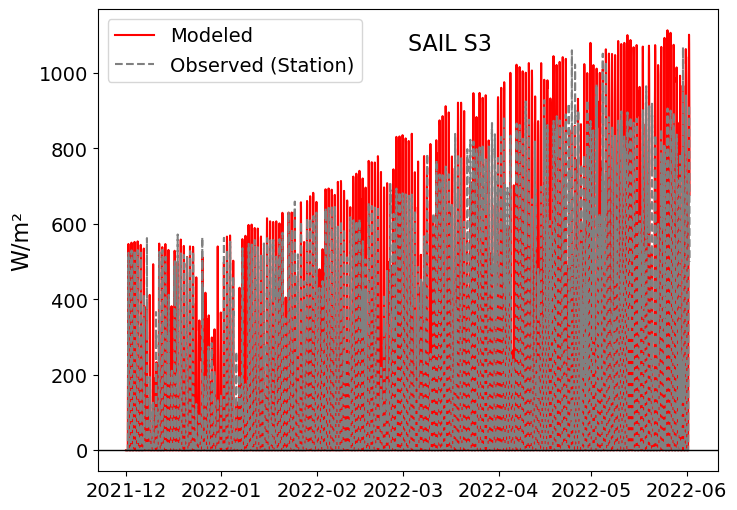

In [9]:
sail_var = 'qc_down_short_hemisp'
sail_var = 'down_short_hemisp'
s3_obs = s3_sail[sail_var].sel(time=slice('2021-12-01', '2022-06-01'))
s3_obs = s3_obs.clip(min=0)

s3_model_smoothed = s3_dsw3.sel(time=slice('2021-12-01', '2022-06-01'))

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 6), sharex=True)



axes.plot(s3_model_smoothed['time'], s3_model_smoothed['dsw3h'], label='Modeled', color='red')
axes.plot(s3_obs['time'], s3_obs, label='Observed (Station)', color='gray', linestyle='--')
axes.axhline(0, color='black', linewidth=1)
axes.text(0.5, 0.95, 'SAIL S3', transform=axes.transAxes,
             fontsize=16, verticalalignment='top', horizontalalignment='left')
axes.set_ylabel('W/m²', fontsize=label_size)
axes.tick_params(axis='both', labelsize=tick_size)
axes.legend(fontsize=legend_size)

plt.show()

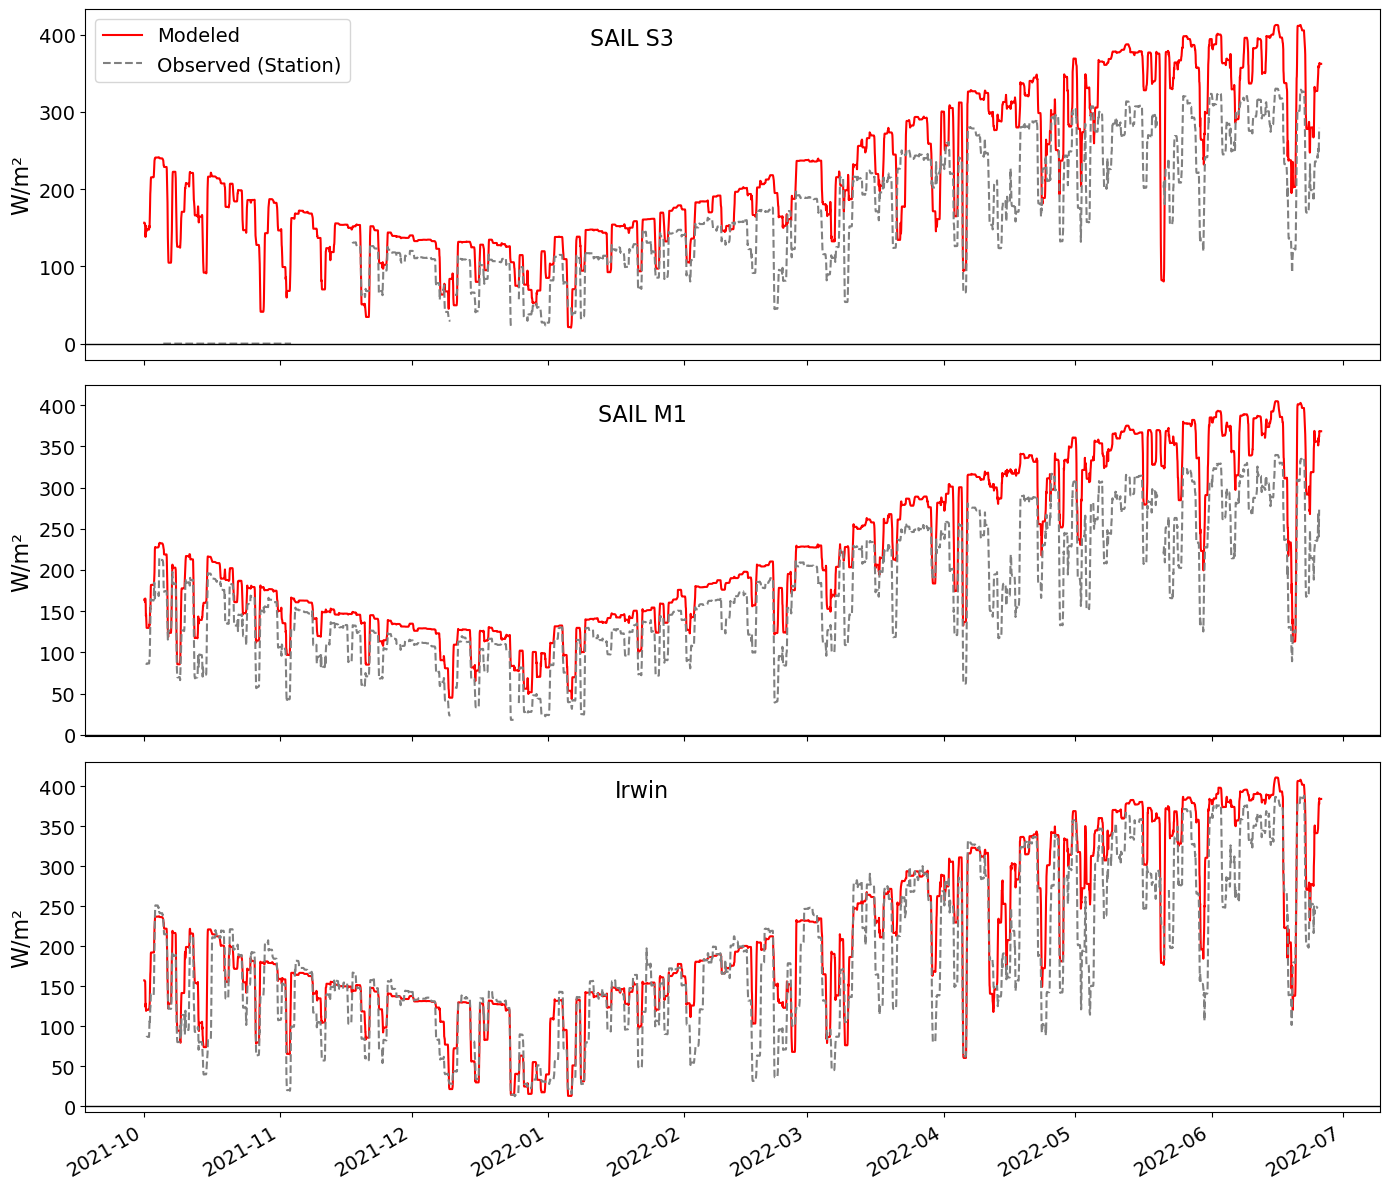

In [10]:
# FIGURE 1
import matplotlib.pyplot as plt
import pandas as pd

# Define Water Year 2022 time range
start_wy2022 = '2021-10-01'
end_wy2022   = '2022-06-25'
win = 24  # Rolling window size

# ======= S3 Station =======
sail_var = 'down_short_hemisp'
# sail_var = 'qc_down_short_hemisp'
s3_obs = s3_sail[sail_var].sel(time=slice(start_wy2022, end_wy2022))
# s3_obs = s3_obs.where(s3_obs >= 0)
s3_obs = s3_obs.clip(min=0)
s3_obs_hourly = s3_obs.resample(time='1h').mean()
s3_obs_smoothed = s3_obs_hourly.rolling(time=win, center=True).mean()
s3_model_smoothed = s3_dsw3.rolling(time=win, center=True).mean().sel(time=slice(start_wy2022, end_wy2022))

# ======= M1 Station =======
m1_obs = m1_sail[sail_var].sel(time=slice(start_wy2022, end_wy2022))
m1_obs_hourly = m1_obs.resample(time='1h').mean()
m1_obs_smoothed = m1_obs_hourly.rolling(time=win, center=True).mean()
m1_model_smoothed = m1_dsw3.rolling(time=win, center=True).mean().sel(time=slice(start_wy2022, end_wy2022))

# ======= Irwin Station (Pandas-based) =======
irwin_pyra_hourly = irwin_pyra.resample('1h').mean()
irwin_pyra_hourly.index = pd.to_datetime(irwin_pyra_hourly.index)
irwin_obs = irwin_pyra_hourly.loc[start_wy2022:end_wy2022]['VIS_IN'].rolling(window=win, center=True).mean()
irwin_obs = irwin_obs.where(irwin_obs > 0)
irwin_model_smoothed = irwin_dsw3.rolling(time=win, center=True).mean().sel(time=slice(start_wy2022, end_wy2022))

# ======= Plotting =======
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 12), sharex=True)

# Common font sizes
title_size = 18
label_size = 16
tick_size = 14
legend_size = 14

# --- S3 Plot ---
axes[0].plot(s3_model_smoothed['time'], s3_model_smoothed['dsw3h'], label='Modeled', color='red')
axes[0].plot(s3_obs_smoothed['time'], s3_obs_smoothed, label='Observed (Station)', color='gray', linestyle='--')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].text(0.39, 0.95, 'SAIL S3', transform=axes[0].transAxes,
             fontsize=16, verticalalignment='top', horizontalalignment='left')
axes[0].set_ylabel('W/m²', fontsize=label_size)
axes[0].tick_params(axis='both', labelsize=tick_size)
axes[0].legend(fontsize=legend_size)

# --- M1 Plot ---
axes[1].plot(m1_model_smoothed['time'], m1_model_smoothed['dsw3h'], label='Modeled', color='red')
axes[1].plot(m1_obs_smoothed['time'], m1_obs_smoothed, label='Observed (M1)', color='gray', linestyle='--')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].text(0.43, 0.95, 'SAIL M1', transform=axes[1].transAxes,
             fontsize=16, va='top', ha='center')
axes[1].set_ylabel('W/m²', fontsize=label_size)
axes[1].tick_params(axis='both', labelsize=tick_size)

# --- Irwin Plot ---
axes[2].plot(irwin_model_smoothed['time'], irwin_model_smoothed['dsw3h'], label='Modeled', color='red')
axes[2].plot(irwin_obs.index, irwin_obs, label='Observed (Irwin)', color='gray', linestyle='--')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].text(0.43, 0.95, 'Irwin', transform=axes[2].transAxes,
             fontsize=16, va='top', ha='center')
axes[2].set_ylabel('W/m²', fontsize=label_size)
axes[2].tick_params(axis='both', labelsize=tick_size)

fig.autofmt_xdate()
plt.tight_layout()



# Save the figure with high quality
svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/topo-split-rmgsa/"
# plt.savefig(svpth + 'f1-seasonal-3.png', dpi=300, bbox_inches='tight')
plt.show()

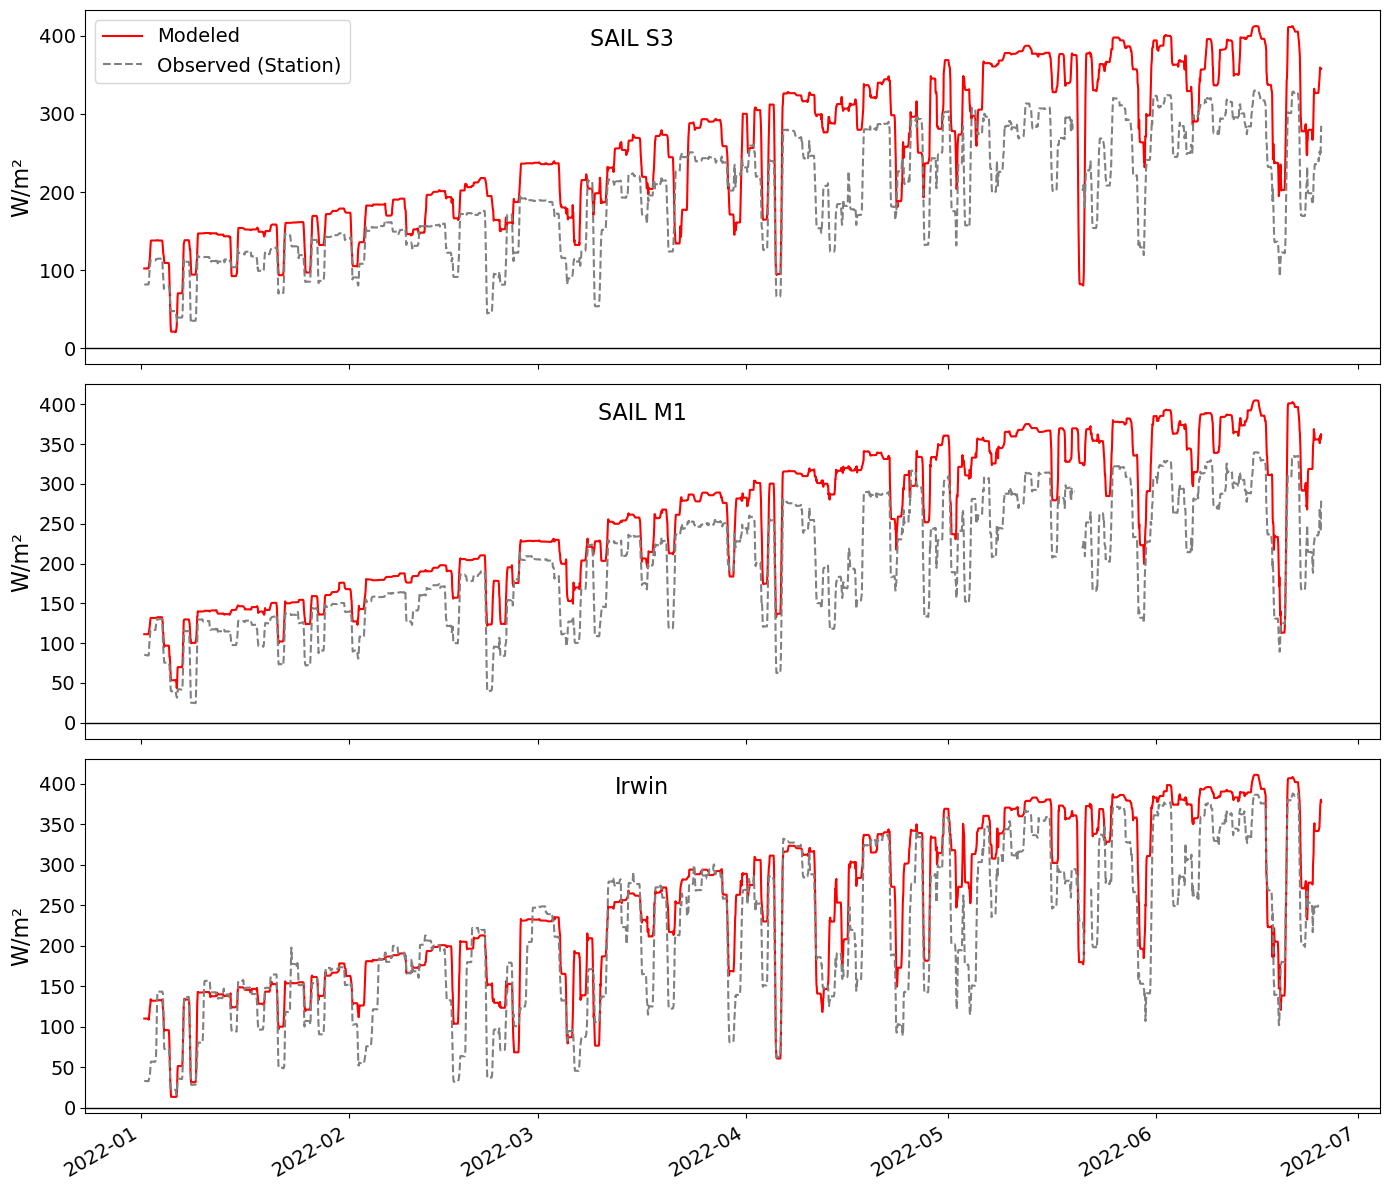

In [38]:
# FIGURE 1
import matplotlib.pyplot as plt
import pandas as pd

# Define Water Year 2022 time range (aligned to full day)
start_wy2022 = '2022-01-01 00:00'
end_wy2022   = '2022-06-25 23:00'
win = 24  # 24-hour rolling window

# ======= S3 Station =======
sail_var = 'down_short_hemisp'
s3_obs = s3_sail[sail_var].sel(time=slice(start_wy2022, end_wy2022)).clip(min=0)
s3_obs_hourly = s3_obs.resample(time='1h').mean()
s3_obs_smoothed = s3_obs_hourly.rolling(time=win, center=True).mean()
s3_model_smoothed = s3_dsw3.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=win, center=True).mean()

# ======= M1 Station =======
m1_obs = m1_sail[sail_var].sel(time=slice(start_wy2022, end_wy2022))
m1_obs_hourly = m1_obs.resample(time='1h').mean()
m1_obs_smoothed = m1_obs_hourly.rolling(time=win, center=True).mean()
m1_model_smoothed = m1_dsw3.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=win, center=True).mean()

# ======= Irwin Station (Pandas-based) =======
irwin_pyra_hourly = irwin_pyra.resample('1h').mean()
irwin_pyra_hourly.index = pd.to_datetime(irwin_pyra_hourly.index)
irwin_hourly = irwin_pyra_hourly.loc[start_wy2022:end_wy2022]
irwin_obs = irwin_hourly['VIS_IN'].rolling(window=win, center=True).mean()
irwin_obs = irwin_obs.where(irwin_obs > 0)
irwin_model_smoothed = irwin_dsw3.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=win, center=True).mean()

# ======= Plotting =======
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 12), sharex=True)

# Font sizes
title_size = 18
label_size = 16
tick_size = 14
legend_size = 14

# --- S3 Plot ---
axes[0].plot(s3_model_smoothed['time'], s3_model_smoothed['dsw3h'], label='Modeled', color='red')
axes[0].plot(s3_obs_smoothed['time'], s3_obs_smoothed, label='Observed (Station)', color='gray', linestyle='--')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].text(0.39, 0.95, 'SAIL S3', transform=axes[0].transAxes,
             fontsize=16, verticalalignment='top', horizontalalignment='left')
axes[0].set_ylabel('W/m²', fontsize=label_size)
axes[0].tick_params(axis='both', labelsize=tick_size)
axes[0].legend(fontsize=legend_size)

# --- M1 Plot ---
axes[1].plot(m1_model_smoothed['time'], m1_model_smoothed['dsw3h'], label='Modeled', color='red')
axes[1].plot(m1_obs_smoothed['time'], m1_obs_smoothed, label='Observed (M1)', color='gray', linestyle='--')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].text(0.43, 0.95, 'SAIL M1', transform=axes[1].transAxes,
             fontsize=16, va='top', ha='center')
axes[1].set_ylabel('W/m²', fontsize=label_size)
axes[1].tick_params(axis='both', labelsize=tick_size)

# --- Irwin Plot ---
axes[2].plot(irwin_model_smoothed['time'], irwin_model_smoothed['dsw3h'], label='Modeled', color='red')
axes[2].plot(irwin_obs.index, irwin_obs, label='Observed (Irwin)', color='gray', linestyle='--')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].text(0.43, 0.95, 'Irwin', transform=axes[2].transAxes,
             fontsize=16, va='top', ha='center')
axes[2].set_ylabel('W/m²', fontsize=label_size)
axes[2].tick_params(axis='both', labelsize=tick_size)

fig.autofmt_xdate()
plt.tight_layout()

# Optional: Save figure
svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/topo-split-rmgsa/"
# plt.savefig(svpth + 'f1-seasonal-3.png', dpi=300, bbox_inches='tight')
plt.show()


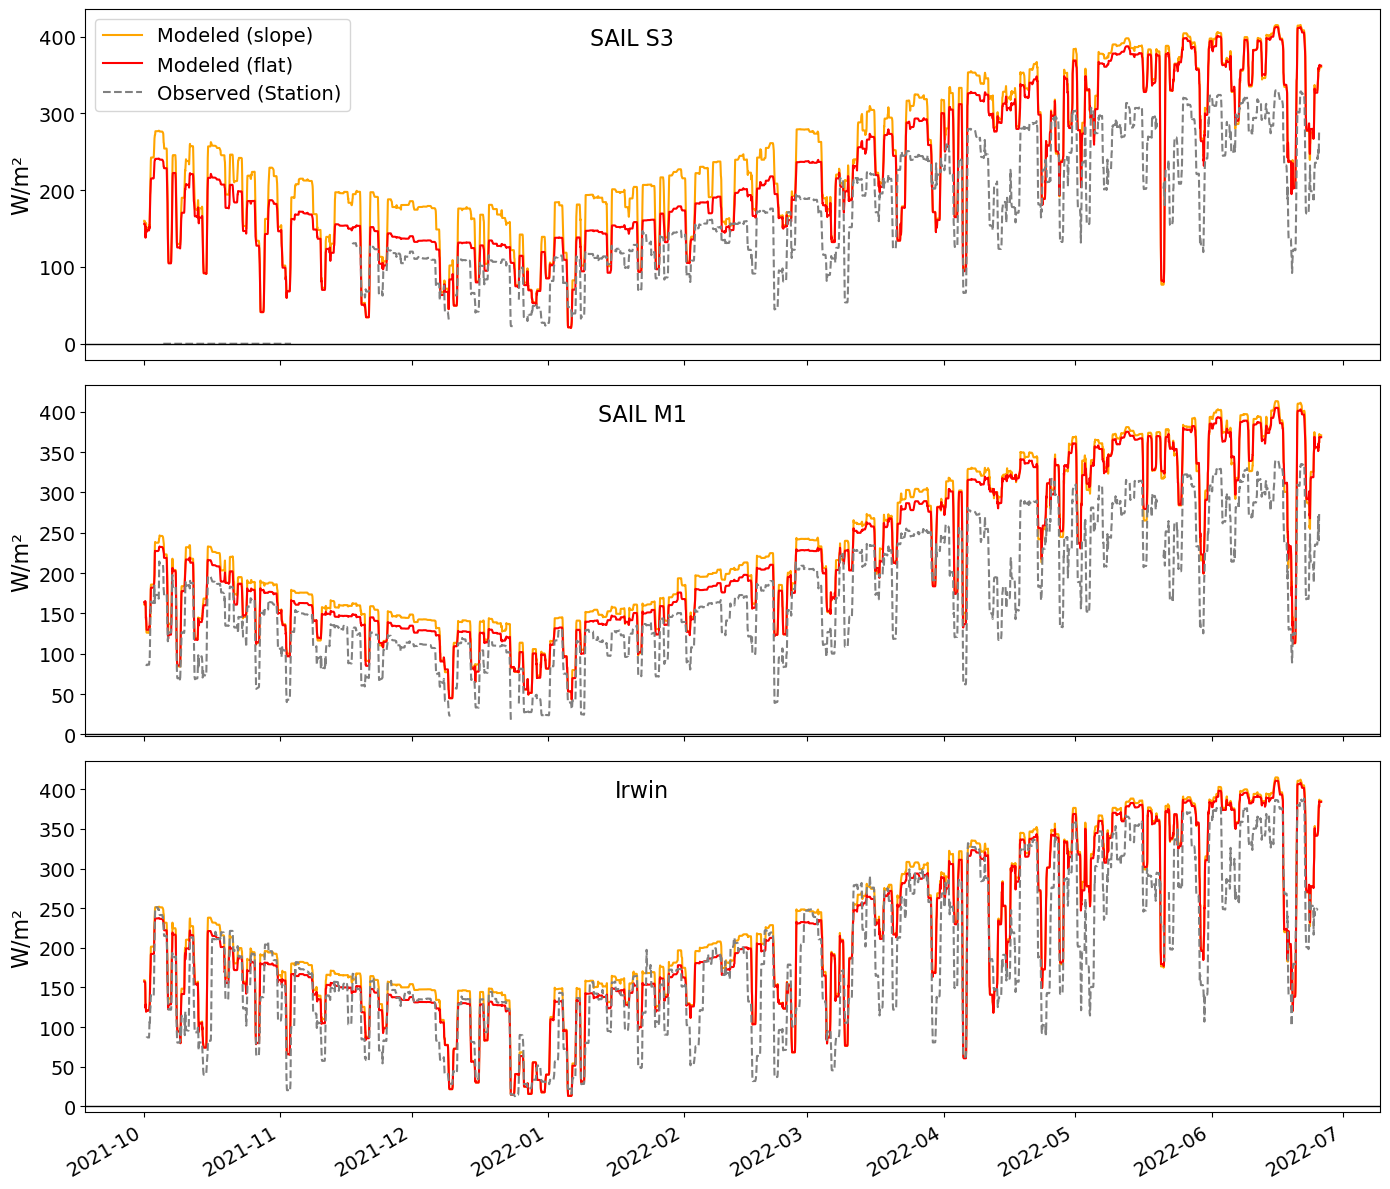

In [17]:
# FIGURE 1
import matplotlib.pyplot as plt
import pandas as pd

# Define Water Year 2022 time range
start_wy2022 = '2021-10-01'
end_wy2022   = '2022-06-25'
win = 24  # Rolling window size

# ======= S3 Station =======
sail_var = 'down_short_hemisp'
# sail_var = 'qc_down_short_hemisp'
s3_obs = s3_sail[sail_var].sel(time=slice(start_wy2022, end_wy2022))
# s3_obs = s3_obs.where(s3_obs >= 0)
s3_obs = s3_obs.clip(min=0)
s3_obs_hourly = s3_obs.resample(time='1h').mean()
s3_obs_smoothed = s3_obs_hourly.rolling(time=win, center=True).mean()
s3_model_smoothed = s3_dsw3.rolling(time=win, center=True).mean().sel(time=slice(start_wy2022, end_wy2022))
#
s3_model_smoothed_slope = s3_dsw30.rolling(time=win, center=True).mean().sel(time=slice(start_wy2022, end_wy2022))

# ======= M1 Station =======
m1_obs = m1_sail[sail_var].sel(time=slice(start_wy2022, end_wy2022))
m1_obs_hourly = m1_obs.resample(time='1h').mean()
m1_obs_smoothed = m1_obs_hourly.rolling(time=win, center=True).mean()
m1_model_smoothed = m1_dsw3.rolling(time=win, center=True).mean().sel(time=slice(start_wy2022, end_wy2022))
#
m1_model_smoothed_slope = m1_dsw30.rolling(time=win, center=True).mean().sel(time=slice(start_wy2022, end_wy2022))


# ======= Irwin Station (Pandas-based) =======
irwin_pyra_hourly = irwin_pyra.resample('1h').mean()
irwin_pyra_hourly.index = pd.to_datetime(irwin_pyra_hourly.index)
irwin_obs = irwin_pyra_hourly.loc[start_wy2022:end_wy2022]['VIS_IN'].rolling(window=win, center=True).mean()
irwin_obs = irwin_obs.where(irwin_obs > 0)
irwin_model_smoothed = irwin_dsw3.rolling(time=win, center=True).mean().sel(time=slice(start_wy2022, end_wy2022))
#
irwin_model_smoothed_slope = irwin_dsw30.rolling(time=win, center=True).mean().sel(time=slice(start_wy2022, end_wy2022))

# ======= Plotting =======
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 12), sharex=True)

# Common font sizes
title_size = 18
label_size = 16
tick_size = 14
legend_size = 14

# --- S3 Plot ---
axes[0].plot(s3_model_smoothed_slope['time'], s3_model_smoothed_slope['dsw3'], label='Modeled (slope)', color='orange')
axes[0].plot(s3_model_smoothed['time'], s3_model_smoothed['dsw3h'], label='Modeled (flat)', color='red')
axes[0].plot(s3_obs_smoothed['time'], s3_obs_smoothed, label='Observed (Station)', color='gray', linestyle='--')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].text(0.39, 0.95, 'SAIL S3', transform=axes[0].transAxes,
             fontsize=16, verticalalignment='top', horizontalalignment='left')
axes[0].set_ylabel('W/m²', fontsize=label_size)
axes[0].tick_params(axis='both', labelsize=tick_size)
axes[0].legend(fontsize=legend_size)

# --- M1 Plot ---
axes[1].plot(m1_model_smoothed_slope['time'], m1_model_smoothed_slope['dsw3'], label='Modeled (slope)', color='orange')
axes[1].plot(m1_model_smoothed['time'], m1_model_smoothed['dsw3h'], label='Modeled (flat)', color='red')
axes[1].plot(m1_obs_smoothed['time'], m1_obs_smoothed, label='Observed (M1)', color='gray', linestyle='--')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].text(0.43, 0.95, 'SAIL M1', transform=axes[1].transAxes,
             fontsize=16, va='top', ha='center')
axes[1].set_ylabel('W/m²', fontsize=label_size)
axes[1].tick_params(axis='both', labelsize=tick_size)

# --- Irwin Plot ---
axes[2].plot(irwin_model_smoothed_slope['time'], irwin_model_smoothed_slope['dsw3'], label='Modeled (slope)', color='orange')
axes[2].plot(irwin_model_smoothed['time'], irwin_model_smoothed['dsw3h'], label='Modeled (flat)', color='red')
axes[2].plot(irwin_obs.index, irwin_obs, label='Observed (Irwin)', color='gray', linestyle='--')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].text(0.43, 0.95, 'Irwin', transform=axes[2].transAxes,
             fontsize=16, va='top', ha='center')
axes[2].set_ylabel('W/m²', fontsize=label_size)
axes[2].tick_params(axis='both', labelsize=tick_size)

fig.autofmt_xdate()
plt.tight_layout()



# Save the figure with high quality
svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/topo-split-rmgsa/"
# plt.savefig(svpth + 'mod_sw_slope_station_bias.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# print(len(s3_bias))
# print(len(m1_bias))
# print(len(irwin_bias))
m1_sail

<xarray.Dataset> Size: 10MB
Dimensions:                        (time: 31299, bound: 2)
Coordinates:
  * time                           (time) datetime64[ns] 250kB 2021-09-01 ......
Dimensions without coordinates: bound
Data variables: (12/70)
    base_time                      (time) datetime64[ns] 250kB ...
    time_offset                    (time) datetime64[ns] 250kB ...
    time_bounds                    (time, bound) datetime64[ns] 501kB ...
    down_short_hemisp              (time) float32 125kB ...
    qc_down_short_hemisp           (time) int32 125kB ...
    up_short_hemisp                (time) float32 125kB ...
    ...                             ...
    qc_temp_net_radiometer         (time) int32 125kB ...
    battery_voltage                (time) float32 125kB ...
    qc_battery_voltage             (time) int32 125kB ...
    lat                            (time) float32 125kB ...
    lon                            (time) float32 125kB ...
    alt                            (time) float32 125kB ...
Attributes: (12/29)
    command_line:            sebs_ingest -s guc -f M1 -RD --max-runtime 0
    Conventions:             ARM-1.3
    process_version:         ingest-sebs-1.7-0.el7
    dod_version:             sebs-b1-1.5
    input_source:            /data/reproc/D240816.14/collection/guc/gucsebsM1...
    site_id:                 guc
    ...                      ...
    qc_bit_1_assessment:     Bad
    qc_bit_2_description:    Value is less than the valid_min.
    qc_bit_2_assessment:     Bad
    qc_bit_3_description:    Value is greater than the valid_max.
    qc_bit_3_assessment:     Bad
    history:                 created by user erwinmj on machine prod-proc5.ad...

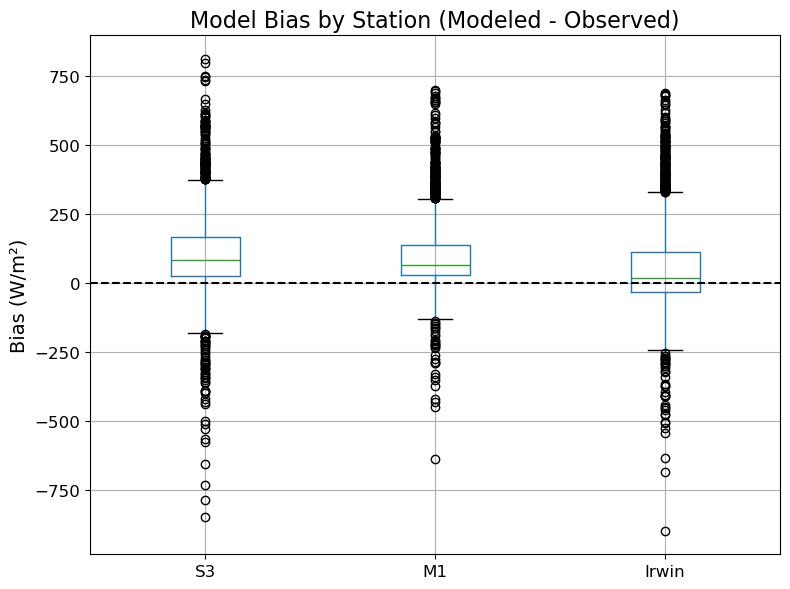

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

# Time range
start_wy2022 = '2021-10-01'
end_wy2022 = '2022-06-25'

# --- S3 Bias ---
s3_obs = s3_sail['down_short_hemisp'].sel(time=slice(start_wy2022, end_wy2022)).clip(min=0).resample(time='1h').mean()
s3_obs = s3_obs[s3_obs > 0] 
s3_model = s3_dsw3['dsw3h'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
s3_obs, s3_model = xr.align(s3_obs, s3_model)
s3_bias = (s3_model - s3_obs).to_series()

# --- M1 Bias ---
m1_obs = m1_sail['down_short_hemisp'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
m1_obs = m1_obs[m1_obs > 0]
m1_model = m1_dsw3['dsw3h'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
m1_obs, m1_model = xr.align(m1_obs, m1_model)
m1_bias = (m1_model - m1_obs).to_series()

# --- Irwin Bias ---
irwin_obs = irwin_pyra['VIS_IN'].resample('1h').mean().loc[start_wy2022:end_wy2022]
irwin_obs = irwin_obs[irwin_obs > 0]
irwin_model = irwin_dsw3['dsw3h'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
irwin_model_df = irwin_model.to_series()
irwin_bias = (irwin_model_df - irwin_obs).dropna()

# --- Combine biases (auto-align on timestamps, outer join) ---
bias_df = pd.concat([s3_bias.rename('S3'),
                     m1_bias.rename('M1'),
                     irwin_bias.rename('Irwin')], axis=1)

# Drop any rows with NaNs
bias_df = bias_df.dropna()

# --- Plot Boxplot ---
plt.figure(figsize=(8, 6))
bias_df.boxplot(column=['S3', 'M1', 'Irwin'])
plt.title('Model Bias by Station (Modeled - Observed)', fontsize=16)
plt.ylabel('Bias (W/m²)', fontsize=14)
plt.axhline(0, color='black', linestyle='--')
plt.grid(True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


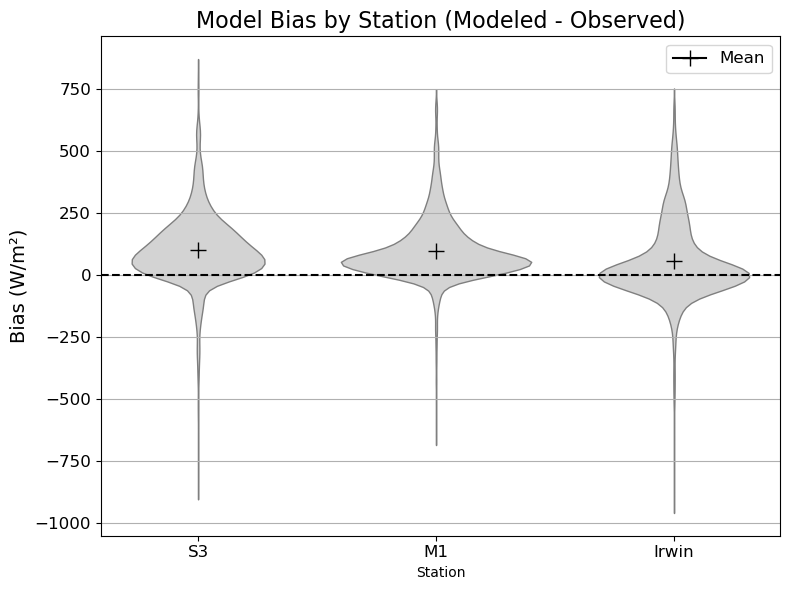

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Melt the DataFrame into long-form for seaborn
bias_long = bias_df.melt(var_name='Station', value_name='Bias')

plt.figure(figsize=(8, 6))
sns.violinplot(data=bias_long, x='Station', y='Bias', inner=None, color='lightgray', linewidth=1)

# Overlay the mean with "+" symbol
means = bias_df.mean()
for i, station in enumerate(means.index):
    plt.plot(i, means[station], marker='+', color='black', markersize=12, label='Mean' if i == 0 else "")

plt.axhline(0, color='black', linestyle='--')
plt.title('Model Bias by Station (Modeled - Observed)', fontsize=16)
plt.ylabel('Bias (W/m²)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, axis='y')

# Add legend only once
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/topo-split-rmgsa/"
# plt.savefig(svpth + 'f2-total-bias.png', dpi=300, bbox_inches='tight')

/scratch/local/u1037042/4398800/ipykernel_4038187/958990111.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=bias_long, x='Station', y='Bias', inner=None, palette=colors, linewidth=1)


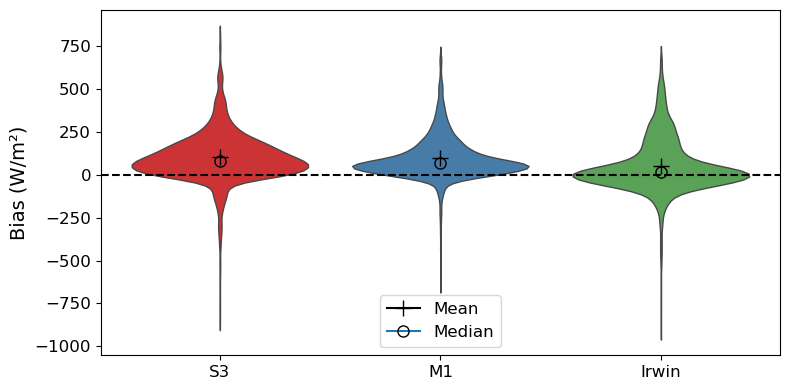

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Melt the DataFrame into long-form for seaborn
bias_long = bias_df.melt(var_name='Station', value_name='Bias')

cmap = plt.get_cmap('Set1')
colors = [cmap(i) for i in range(3)]  

# Create the violin plot (no internal stats shown)
plt.figure(figsize=(8, 4))
sns.violinplot(data=bias_long, x='Station', y='Bias', inner=None, palette=colors, linewidth=1)
plt.xlabel('')
# Overlay mean and median
means = bias_df.mean()
medians = bias_df.median()

for i, station in enumerate(bias_df.columns):
    # Mean marker
    plt.plot(i, means[station], marker='+', color='black', markersize=12, label='Mean' if i == 0 else "")
    # Median marker
    plt.plot(i, medians[station], marker='o', markerfacecolor='none', markeredgecolor='black', markersize=8, label='Median' if i == 0 else "")

# Axis styling
plt.axhline(0, color='black', linestyle='--')
# plt.title('Model Bias by Station (Modeled - Observed)', fontsize=16)
plt.ylabel('Bias (W/m²)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.grid(True, axis='y')

# Add legend only once
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/topo-split-rmgsa/"
# plt.savefig(svpth + 'f2-total-bias-2.png', dpi=300, bbox_inches='tight')

In [34]:
import numpy as np

rmse = np.sqrt((bias_df ** 2).mean())
print("RMSE by station (W/m²):")
print(rmse)


RMSE by station (W/m²):
S3       175.829479
M1       155.735133
Irwin    164.694440
dtype: float64


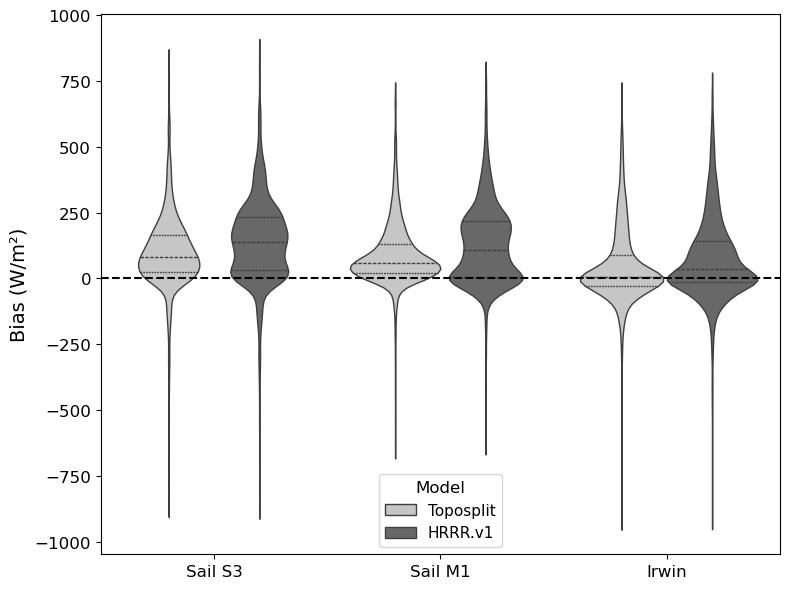

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Time range
start_wy2022 = '2021-10-01'
end_wy2022 = '2022-06-25'

# --- Helper function to calculate bias ---
def compute_bias(obs, model):
    obs = obs.sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
    obs = obs[obs > 0]
    model = model.sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
    obs, model = xr.align(obs, model)
    return (model - obs).to_series()

# --- S3 ---
s3_obs = s3_sail['down_short_hemisp'].clip(min=0)
s3_bias_3 = compute_bias(s3_obs, s3_dsw3['dsw3h']).rename('Sail S3')
s3_bias_1 = compute_bias(s3_obs, s3_dsw1['dsw1']).rename('Sail S3')

# --- M1 ---
m1_obs = m1_sail['down_short_hemisp']
m1_bias_3 = compute_bias(m1_obs, m1_dsw3['dsw3h']).rename('Sail M1')
m1_bias_1 = compute_bias(m1_obs, m1_dsw1['dsw1']).rename('Sail M1')

# --- Irwin ---
irwin_obs = irwin_pyra['VIS_IN'].resample('1h').mean().loc[start_wy2022:end_wy2022]
irwin_obs = irwin_obs[irwin_obs > 0]
irwin_model_3 = irwin_dsw3['dsw3h'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean().to_series()
irwin_model_1 = irwin_dsw1['dsw1'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean().to_series()
irwin_bias_3 = (irwin_model_3 - irwin_obs).dropna().rename('Irwin')
irwin_bias_1 = (irwin_model_1 - irwin_obs).dropna().rename('Irwin')

# --- Combine all bias data ---
def prepare_bias_df(bias_series, model_name):
    df = bias_series.reset_index()
    df.columns = ['Time', 'Bias']
    df['Station'] = bias_series.name  # Use the name of the Series for station
    df['Model'] = model_name
    return df

bias_all = pd.concat([
    prepare_bias_df(s3_bias_3, 'Toposplit'),
    prepare_bias_df(s3_bias_1, 'HRRR.v1'),
    prepare_bias_df(m1_bias_3, 'Toposplit'),
    prepare_bias_df(m1_bias_1, 'HRRR.v1'),
    prepare_bias_df(irwin_bias_3, 'Toposplit'),
    prepare_bias_df(irwin_bias_1, 'HRRR.v1')
])

# --- Plot ---
plt.figure(figsize=(8, 6))
sns.violinplot(data=bias_all, x='Station', y='Bias', hue='Model',
               split=False, inner='quartile', palette='Greys', linewidth=1)

plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Bias (W/m²)', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Model', fontsize=11, title_fontsize=12)
plt.tight_layout()
plt.show()
svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/topo-split-rmgsa/"
# plt.savefig(svpth + 'station-bias-models.png', dpi=300, bbox_inches='tight')

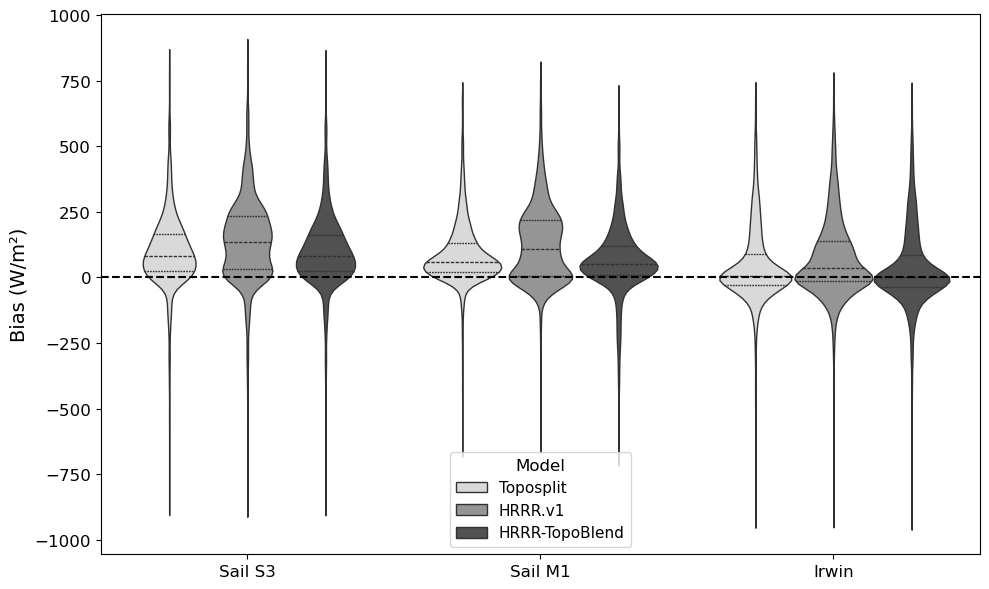

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Time range
start_wy2022 = '2021-10-01'
end_wy2022 = '2022-06-25'

# --- Helper function to calculate bias ---
def compute_bias(obs, model):
    obs = obs.sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
    obs = obs[obs > 0]
    model = model.sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
    obs, model = xr.align(obs, model)
    return (model - obs).to_series()

# --- S3 ---
s3_obs = s3_sail['down_short_hemisp'].clip(min=0)
s3_bias_3 = compute_bias(s3_obs, s3_dsw3['dsw3h']).rename('Sail S3')
s3_bias_1 = compute_bias(s3_obs, s3_dsw1['dsw1']).rename('Sail S3')
s3_model_b = s3_dsw30['dsw3'] - (s3_dsw1['dsw1'] - s3_dsw3['dsw3h'])
s3_bias_b = compute_bias(s3_obs, s3_model_b).rename('Sail S3')

# --- M1 ---
m1_obs = m1_sail['down_short_hemisp']
m1_bias_3 = compute_bias(m1_obs, m1_dsw3['dsw3h']).rename('Sail M1')
m1_bias_1 = compute_bias(m1_obs, m1_dsw1['dsw1']).rename('Sail M1')
m1_model_b = m1_dsw30['dsw3'] - (m1_dsw1['dsw1'] - m1_dsw3['dsw3h'])
m1_bias_b = compute_bias(m1_obs, m1_model_b).rename('Sail M1')

# --- Irwin ---
irwin_obs = irwin_pyra['VIS_IN'].resample('1h').mean().loc[start_wy2022:end_wy2022]
irwin_obs = irwin_obs[irwin_obs > 0]
irwin_model_3 = irwin_dsw3['dsw3h'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean().to_series()
irwin_model_1 = irwin_dsw1['dsw1'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean().to_series()
irwin_model_b = (irwin_dsw30['dsw3'] - (irwin_dsw1['dsw1'] - irwin_dsw3['dsw3h'])).sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean().to_series()

irwin_bias_3 = (irwin_model_3 - irwin_obs).dropna().rename('Irwin')
irwin_bias_1 = (irwin_model_1 - irwin_obs).dropna().rename('Irwin')
irwin_bias_b = (irwin_model_b - irwin_obs).dropna().rename('Irwin')

# --- Combine all bias data ---
def prepare_bias_df(bias_series, model_name):
    df = bias_series.reset_index()
    df.columns = ['Time', 'Bias']
    df['Station'] = bias_series.name  # Use the name of the Series for station
    df['Model'] = model_name
    return df

bias_all = pd.concat([
    prepare_bias_df(s3_bias_3, 'Toposplit'),
    prepare_bias_df(s3_bias_1, 'HRRR.v1'),
    prepare_bias_df(s3_bias_b, 'HRRR-TopoBlend'),

    prepare_bias_df(m1_bias_3, 'Toposplit'),
    prepare_bias_df(m1_bias_1, 'HRRR.v1'),
    prepare_bias_df(m1_bias_b, 'HRRR-TopoBlend'),

    prepare_bias_df(irwin_bias_3, 'Toposplit'),
    prepare_bias_df(irwin_bias_1, 'HRRR.v1'),
    prepare_bias_df(irwin_bias_b, 'HRRR-TopoBlend')
])

# --- Plot ---
plt.figure(figsize=(10, 6))
sns.violinplot(data=bias_all, x='Station', y='Bias', hue='Model',
               split=False, inner='quartile', palette='Greys', linewidth=1)

plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Bias (W/m²)', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Model', fontsize=11, title_fontsize=12)
plt.tight_layout()
plt.show()


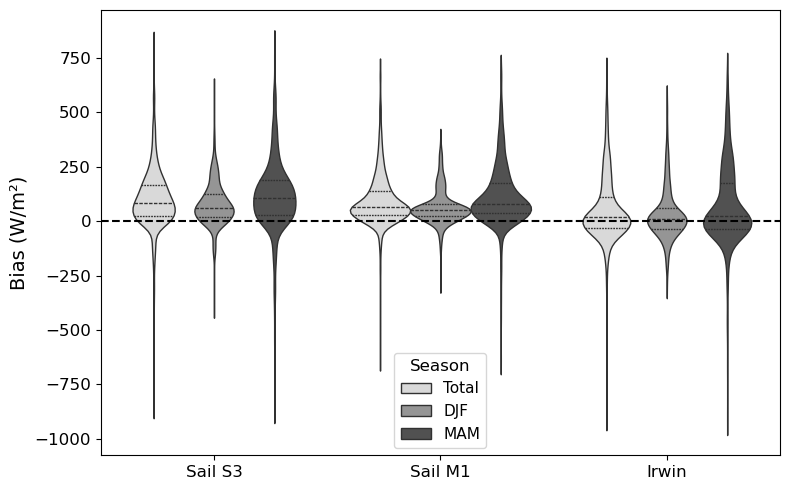

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Time range
start_wy2022 = '2021-10-01'
end_wy2022 = '2022-06-25'

# --- S3 Bias ---
s3_obs = s3_sail['down_short_hemisp'].sel(time=slice(start_wy2022, end_wy2022)).clip(min=0).resample(time='1h').mean()
s3_obs = s3_obs[s3_obs > 0] 
s3_model = s3_dsw3['dsw3h'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
s3_obs, s3_model = xr.align(s3_obs, s3_model)
s3_bias = (s3_model - s3_obs).to_series()

# --- M1 Bias ---
m1_obs = m1_sail['down_short_hemisp'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
m1_obs = m1_obs[m1_obs > 0]
m1_model = m1_dsw3['dsw3h'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
m1_obs, m1_model = xr.align(m1_obs, m1_model)
m1_bias = (m1_model - m1_obs).to_series()

# --- Irwin Bias ---
irwin_obs = irwin_pyra['VIS_IN'].resample('1h').mean().loc[start_wy2022:end_wy2022]
irwin_obs = irwin_obs[irwin_obs > 0]
irwin_model = irwin_dsw3['dsw3h'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
irwin_model_df = irwin_model.to_series()
irwin_bias = (irwin_model_df - irwin_obs).dropna()

# --- Combine into DataFrame ---
bias_df = pd.concat([
    s3_bias.rename('Sail S3'),
    m1_bias.rename('Sail M1'),
    irwin_bias.rename('Irwin')
], axis=1).dropna()

# --- Create seasonal masks ---
bias_df['month'] = bias_df.index.month

def seasonal_subset(df, months):
    return df[df['month'].isin(months)].drop(columns='month')

total_bias = bias_df.drop(columns='month')
djf_bias = seasonal_subset(bias_df, [12, 1, 2])
mam_bias = seasonal_subset(bias_df, [3, 4, 5])

# --- Melt each into long-form with 'Season' label ---
def melt_and_label(df, season):
    melted = df.melt(var_name='Station', value_name='Bias')
    melted['Season'] = season
    return melted

total_long = melt_and_label(total_bias, 'Total')
djf_long = melt_and_label(djf_bias, 'DJF')
mam_long = melt_and_label(mam_bias, 'MAM')

# --- Combine all into one DataFrame ---
bias_long_all = pd.concat([total_long, djf_long, mam_long], axis=0)

# --- Create violin plot ---
plt.figure(figsize=(8, 5))
sns.violinplot(data=bias_long_all, x='Station', y='Bias', hue='Season',
               split=False, inner='quartile', palette='Greys', linewidth=1)

plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Bias (W/m²)', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Season', fontsize=11, title_fontsize=12)
plt.tight_layout()
plt.show()


In [29]:
# Group by station and model
grouped = bias_all.groupby(['Station', 'Model'])

# Compute statistics
stats = []
for (station, model), group in grouped:
    mean_bias = group['Bias'].mean()
    median_bias = group['Bias'].median()
    rmse = np.sqrt(np.mean(group['Bias'] ** 2))  # manual RMSE
    stats.append({
        'Station': station,
        'Model': model,
        'Mean Bias (W/m²)': mean_bias,
        'Median Bias (W/m²)': median_bias,
        'RMSE (W/m²)': rmse
    })

# Create a summary DataFrame
stats_df = pd.DataFrame(stats)
stats_df = stats_df.sort_values(by=['Station', 'Model'])

# Print nicely
print(stats_df.to_string(index=False))


Station          Model  Mean Bias (W/m²)  Median Bias (W/m²)  RMSE (W/m²)
  Irwin HRRR-TopoBlend         36.296744           -0.079949   155.913089
  Irwin        HRRR.v1         72.320309           34.691795   171.312244
  Irwin      Toposplit         46.920495            7.279109   153.647926
Sail M1 HRRR-TopoBlend         66.543266           52.461990   150.209708
Sail M1        HRRR.v1        127.853687          106.563690   195.770266
Sail M1      Toposplit         89.718373           59.820648   148.680692
Sail S3 HRRR-TopoBlend         99.049832           81.196327   173.758915
Sail S3        HRRR.v1        141.683219          136.701904   214.765317
Sail S3      Toposplit        101.653825           83.053146   175.721395


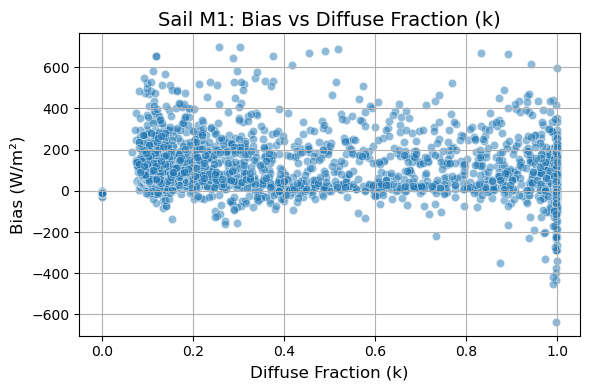

In [16]:
# --- Resample and align ---
k_m1 = m1_k.sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()

# Example with Toposplit
model_m1 = m1_dsw3['dsw3h'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
obs_m1 = m1_sail['down_short_hemisp'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
obs_m1 = obs_m1.where(obs_m1 > 0)

# Align all
obs_m1, model_m1, k_m1 = xr.align(obs_m1, model_m1, k_m1)
bias_m1 = (model_m1 - obs_m1).to_series()
k_m1_series = k_m1['k'].to_series()

# Drop NaNs
df_m1 = pd.DataFrame({'Bias': bias_m1, 'k': k_m1_series}).dropna()


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_m1, x='k', y='Bias', alpha=0.5)
plt.title('Sail M1: Bias vs Diffuse Fraction (k)', fontsize=14)
plt.xlabel('Diffuse Fraction (k)', fontsize=12)
plt.ylabel('Bias (W/m²)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


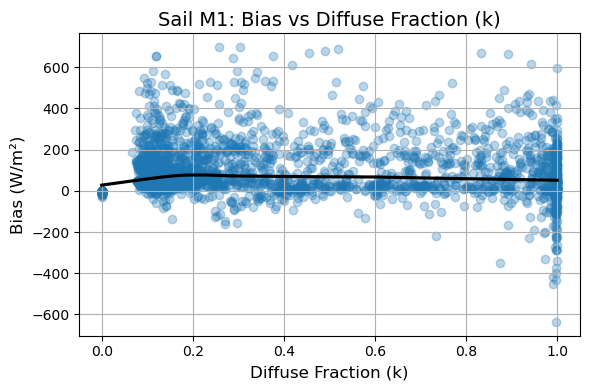

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Resample and align ---
k_m1 = m1_k.sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()

model_m1 = m1_dsw3['dsw3h'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
obs_m1 = m1_sail['down_short_hemisp'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
obs_m1 = obs_m1.where(obs_m1 > 0)

# Align time series
obs_m1, model_m1, k_m1 = xr.align(obs_m1, model_m1, k_m1)
bias_m1 = (model_m1 - obs_m1).to_series()
k_m1_series = k_m1['k'].to_series()

# Drop missing values
df_m1 = pd.DataFrame({'Bias': bias_m1, 'k': k_m1_series}).dropna()

# --- Plot with smooth curve and standard error ---
plt.figure(figsize=(6, 4))
sns.regplot(data=df_m1, x='k', y='Bias', lowess=True, scatter_kws={'alpha': 0.3}, line_kws={'color': 'black'})
plt.title('Sail M1: Bias vs Diffuse Fraction (k)', fontsize=14)
plt.xlabel('Diffuse Fraction (k)', fontsize=12)
plt.ylabel('Bias (W/m²)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# --- Resample and align ---
k_irwin = irwin_k.sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
model_irwin = irwin_dsw3['dsw3h'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
obs_irwin = irwin_pyra['VIS_IN'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
obs_irwin = obs_irwin.where(obs_irwin > 0)

# Align all
obs_irwin, model_irwin, k_irwin = xr.align(obs_irwin, model_irwin, k_irwin)
bias_irwin = (model_irwin - obs_irwin).to_series()
k_irwin_series = k_irwin['k'].to_series()

# Drop NaNs
df_irwin = pd.DataFrame({'Bias': bias_irwin, 'k': k_irwin_series}).dropna()

# --- Smooth curve using lowess for more control ---
lowess_result = lowess(df_irwin['Bias'], df_irwin['k'], frac=0.05)  # More sinuous

# --- Plot ---
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_irwin, x='k', y='Bias', alpha=0.3, label='Hourly Values')
plt.plot(lowess_result[:, 0], lowess_result[:, 1], color='black', label='LOWESS Fit')
plt.title('Irwin: Bias vs Diffuse Fraction (k)', fontsize=14)
plt.xlabel('Diffuse Fraction (k)', fontsize=12)
plt.ylabel('Bias (W/m²)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


AttributeError: 'Series' object has no attribute 'sel'

In [15]:
k_m1


<xarray.Dataset> Size: 77kB
Dimensions:  (time: 6432)
Coordinates:
    x        float32 4B 3.278e+05
    y        float32 4B 4.314e+06
  * time     (time) datetime64[ns] 51kB 2021-10-01 ... 2022-06-25T23:00:00
Data variables:
    k        (time) float32 26kB 0.9979 0.0 0.0 0.0 ... 0.1129 0.2194 0.2773

/scratch/local/u1037042/4346867/ipykernel_3312057/2698939570.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mean = bias_df.resample('M').mean()
/scratch/local/u1037042/4346867/ipykernel_3312057/2698939570.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_std = bias_df.resample('M').std()


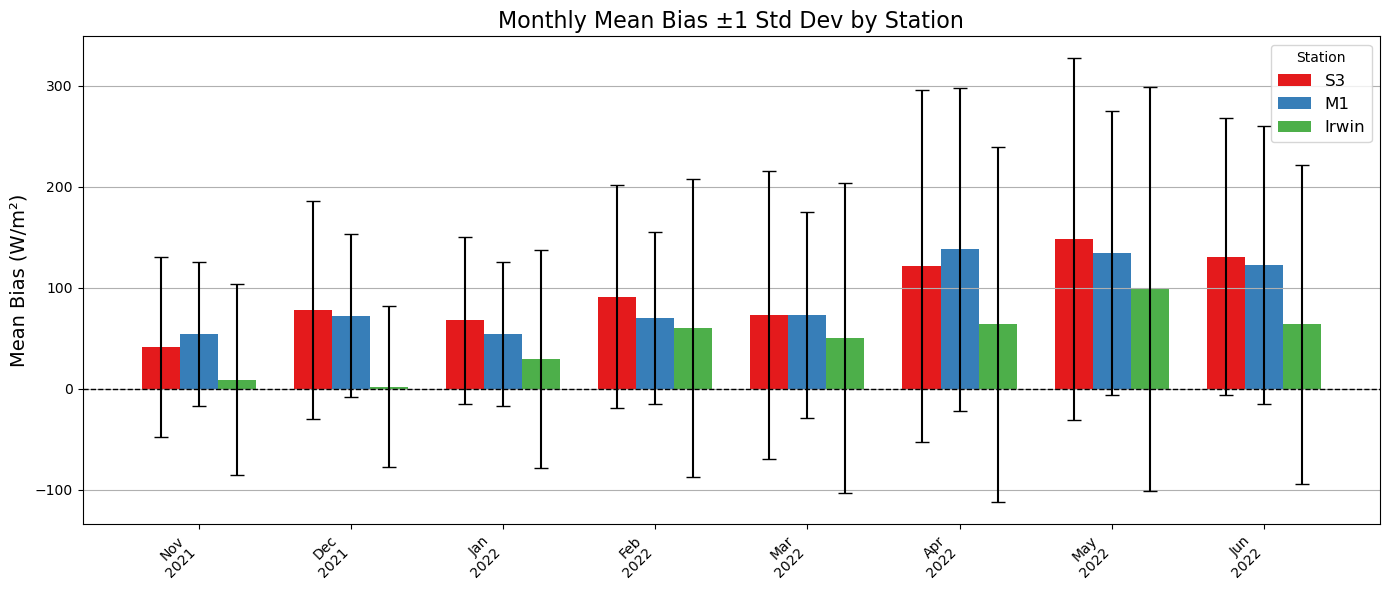

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure bias_df has a DateTime index
bias_df = bias_df.copy()
bias_df.index = pd.to_datetime(bias_df.index)

# Resample by month, then compute mean and std
monthly_mean = bias_df.resample('M').mean()
monthly_std = bias_df.resample('M').std()

# Plotting
stations = ['S3', 'M1', 'Irwin']
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
cmap = plt.get_cmap('Set1')
colors = [cmap(i) for i in range(3)]  

months = monthly_mean.index.strftime('%b\n%Y')  # 'Jan\n2022', etc.
x = np.arange(len(months))  # positions for groups
width = 0.25  # bar width

plt.figure(figsize=(14, 6))

for i, station in enumerate(stations):
    offset = (i - 1) * width  # centers the bars
    plt.bar(x + offset,
            monthly_mean[station],
            yerr=monthly_std[station],
            width=width,
            label=station,
            color=colors[i],
            capsize=5)

# Formatting
plt.xticks(ticks=x, labels=months, rotation=45, ha='right')
plt.ylabel('Mean Bias (W/m²)', fontsize=14)
plt.title('Monthly Mean Bias ±1 Std Dev by Station', fontsize=16)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.legend(title='Station', fontsize=12)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/topo-split-rmgsa/"
# plt.savefig(svpth + 'f2-total-bias.png', dpi=300, bbox_inches='tight')

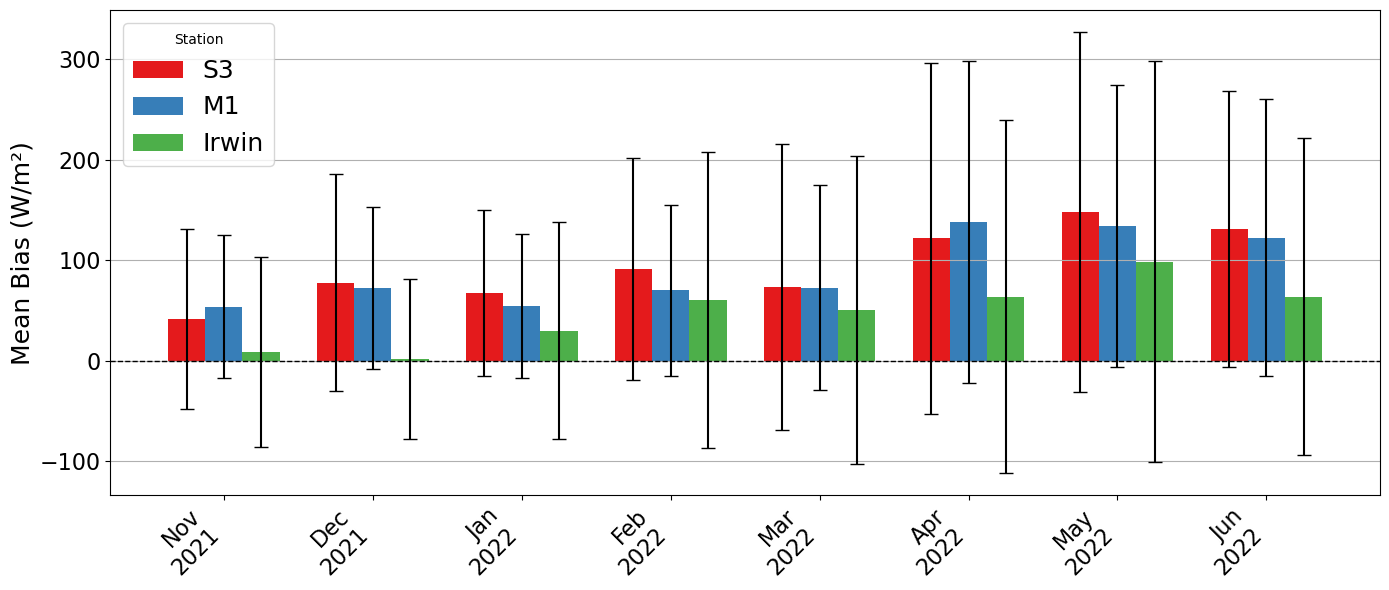

In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure bias_df has a DateTime index
bias_df = bias_df.copy()
bias_df.index = pd.to_datetime(bias_df.index)

# Exclude October values for S3 (assuming the issue is related to October 2021)
bias_df['S3'] = bias_df['S3'][bias_df.index.month != 10]

# Resample by month, then compute mean and std
monthly_mean = bias_df.resample('ME').mean()
monthly_std = bias_df.resample('ME').std()

# Plotting
stations = ['S3', 'M1', 'Irwin']
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
cmap = plt.get_cmap('Set1')
colors = [cmap(i) for i in range(3)]  
months = monthly_mean.index.strftime('%b\n%Y')  # 'Jan\n2022', etc.
x = np.arange(len(months))  # positions for groups
width = 0.25  # bar width

plt.figure(figsize=(14, 6))

for i, station in enumerate(stations):
    offset = (i - 1) * width  # centers the bars
    plt.bar(x + offset,
            monthly_mean[station],
            yerr=monthly_std[station],
            width=width,
            label=station,
            color=colors[i],
            capsize=5)

# Formatting
plt.xticks(ticks=x, labels=months, rotation=45, ha='right', fontsize=16)
plt.ylabel('Mean Bias (W/m²)', fontsize=18)
# plt.title('Monthly Mean Bias ±1 Std Dev by Station', fontsize=20)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.legend(title='Station', fontsize=18)
plt.grid(True, axis='y')
axes[2].set_ylabel('W/m²', fontsize=16)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()
svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/topo-split-rmgsa/"
# plt.savefig(svpth + 'f3-seasonal-bias-bar.png', dpi=300, bbox_inches='tight')

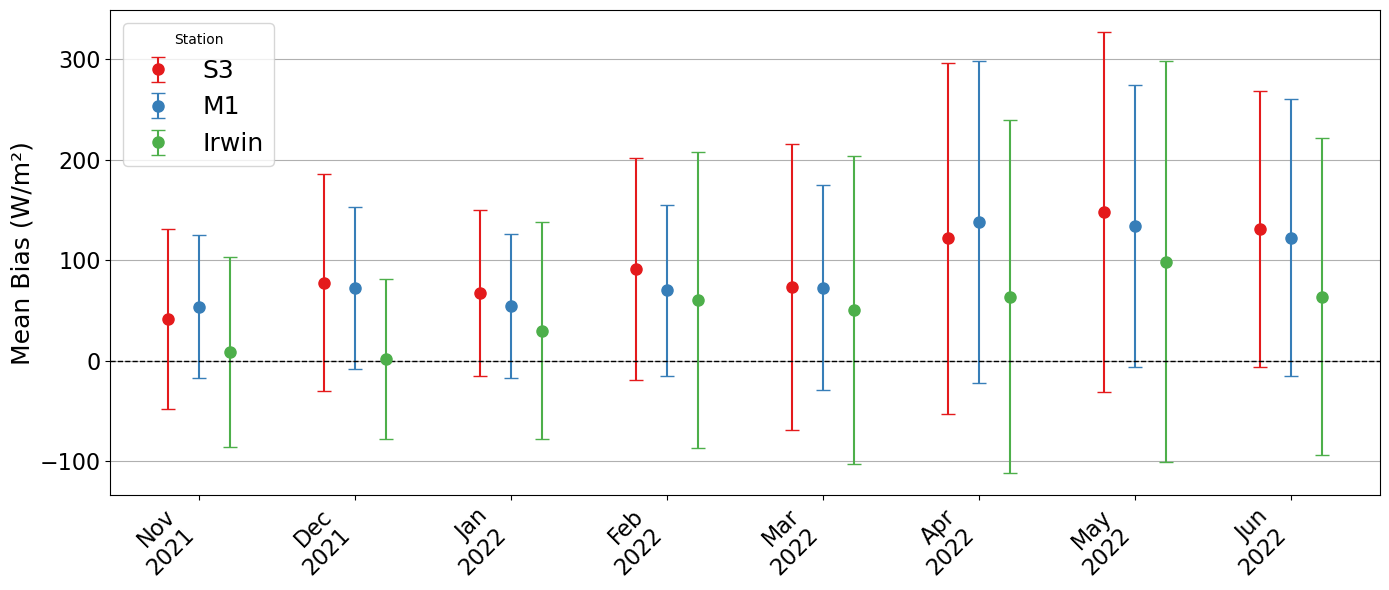

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure bias_df has a DateTime index
bias_df = bias_df.copy()
bias_df.index = pd.to_datetime(bias_df.index)

# Exclude October values for S3
bias_df['S3'] = bias_df['S3'][bias_df.index.month != 10]

# Resample by month, then compute mean and std
monthly_mean = bias_df.resample('ME').mean()
monthly_std = bias_df.resample('ME').std()

# Plotting
stations = ['S3', 'M1', 'Irwin']
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
cmap = plt.get_cmap('Set1')
colors = [cmap(i) for i in range(3)]  
months = monthly_mean.index.strftime('%b\n%Y')
x = np.arange(len(months))

plt.figure(figsize=(14, 6))

for i, station in enumerate(stations):
    offset = (i - 1) * 0.2  # small horizontal offset to separate the dots
    plt.errorbar(x + offset,
                 monthly_mean[station],
                 yerr=monthly_std[station],
                 fmt='o',  # circle markers
                 label=station,
                 color=colors[i],
                 capsize=5,
                 markersize=8,
                 linestyle='None')  # no connecting lines

# Formatting
plt.xticks(ticks=x, labels=months, rotation=45, ha='right', fontsize=16)
plt.ylabel('Mean Bias (W/m²)', fontsize=18)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.legend(title='Station', fontsize=18)
plt.grid(True, axis='y')
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()
svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/topo-split-rmgsa/"
# plt.savefig(svpth + 'f3-seasonal-bias-scatter.png', dpi=300, bbox_inches='tight')

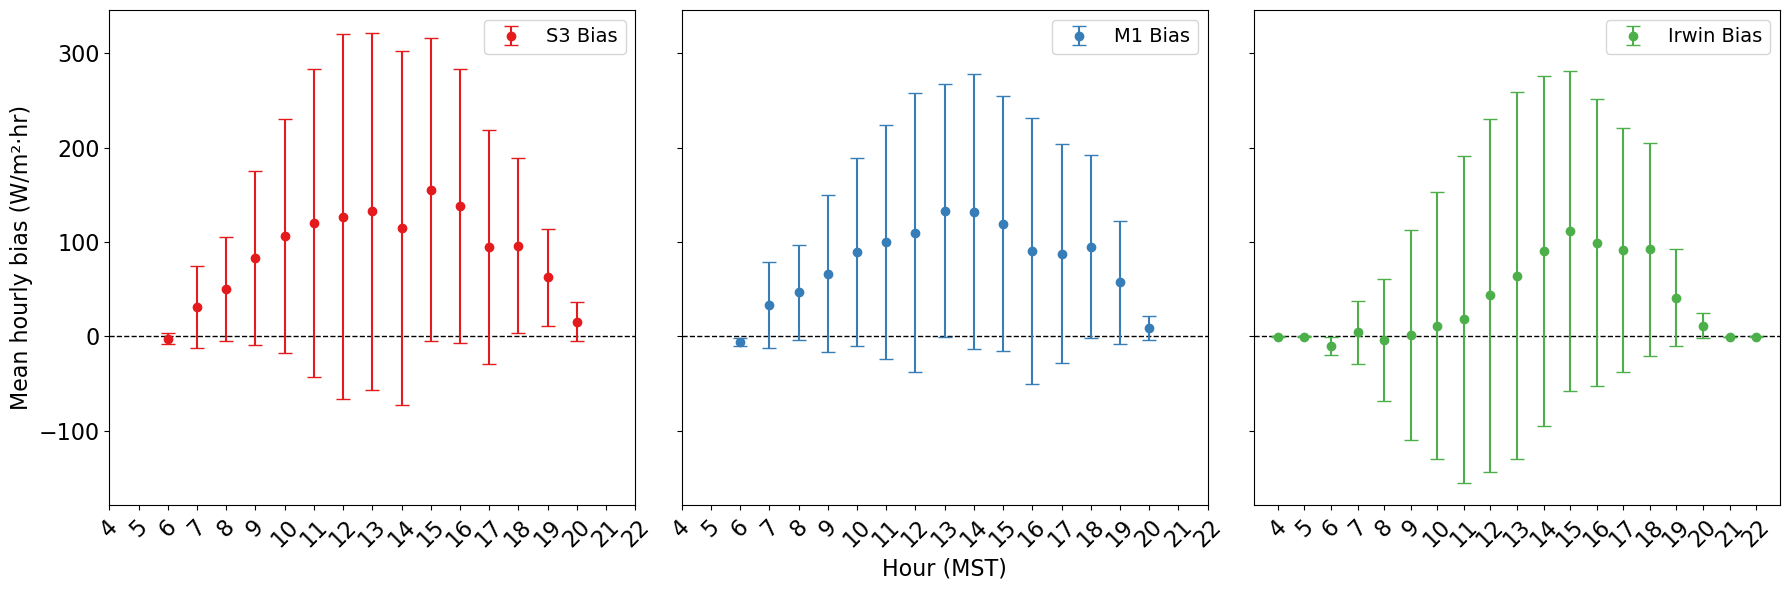

In [64]:

# Time range
start_wy2022 = '2021-10-01'
end_wy2022 = '2022-06-25'

# --- S3 Bias ---
s3_obs = s3_sail['down_short_hemisp'].sel(time=slice(start_wy2022, end_wy2022)).clip(min=0).resample(time='1h').mean()
s3_obs = s3_obs[s3_obs > 0]
s3_model = s3_dsw3['dsw3h'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
s3_obs, s3_model = xr.align(s3_obs, s3_model)
s3_bias = (s3_model - s3_obs).to_series()

# --- M1 Bias ---
m1_obs = m1_sail['down_short_hemisp'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
m1_obs = m1_obs[m1_obs > 0]
m1_model = m1_dsw3['dsw3h'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
m1_obs, m1_model = xr.align(m1_obs, m1_model)
m1_bias = (m1_model - m1_obs).to_series()

# --- Irwin Bias ---
irwin_obs = irwin_pyra['VIS_IN'].resample('1h').mean().loc[start_wy2022:end_wy2022]
irwin_obs = irwin_obs[irwin_obs > 0]
irwin_model = irwin_dsw3['dsw3h'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
irwin_model_df = irwin_model.to_series()
irwin_bias = (irwin_model_df - irwin_obs).dropna()

# Convert indexes to timezone-aware (MST)
s3_bias_mst = s3_bias
m1_bias_mst = m1_bias
irwin_bias_mst = irwin_bias

s3_bias_mst.index = s3_bias_mst.index.tz_localize('UTC').tz_convert('US/Mountain')
m1_bias_mst.index = m1_bias_mst.index.tz_localize('UTC').tz_convert('US/Mountain')
irwin_bias_mst.index = irwin_bias_mst.index.tz_localize('UTC').tz_convert('US/Mountain')

# Store series in lists for easy iteration
bias_series = [s3_bias_mst, m1_bias_mst, irwin_bias_mst]
station_names = ['S3', 'M1', 'Irwin']

# colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
cmap = plt.get_cmap('Set1')
colors = [cmap(i) for i in range(3)]  

# Set up subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (bias, name) in enumerate(zip(bias_series, station_names)):
    # Group by hour of day
    hourly_bias = bias.groupby(bias.index.hour).mean()
    # hourly_bias = bias.groupby(bias.index.hour).median()

    hourly_std = bias.groupby(bias.index.hour).std()

    # Filter for daytime hours
    hour_range = hourly_bias.loc[4:22]
    std_range = hourly_std.loc[4:22]

    ax = axes[i]
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.errorbar(hour_range.index, hour_range, yerr=std_range, fmt='o',
                color=colors[i], capsize=5, label=f'{name} Bias')

    # ax.set_title(f'{name} Diurnal Bias', fontsize=16)
    if i == 1:
        ax.set_xlabel('Hour (MST)', fontsize=16)
    ax.set_xticks(range(4, 23))
    ax.set_xticklabels([f'{h}' for h in range(4, 23)], rotation=45)
    ax.tick_params(axis='both', labelsize=16)
    # plt.tick_params(axis='both', labelsize=16)
    ax.legend(fontsize=14)
    ax.grid(False)

# Only the first subplot gets a shared y-axis label
axes[0].set_ylabel('Mean hourly bias (W/m²·hr)', fontsize=16)

plt.tight_layout()
plt.show()
svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/topo-split-rmgsa/"
# plt.savefig(svpth + 'f4-daily-scatter.png', dpi=300, bbox_inches='tight')

In [ ]:

# Time range
start_wy2022 = '2021-10-01'
end_wy2022 = '2022-06-25'

# --- S3 Bias ---
s3_obs = s3_sail['down_short_hemisp'].sel(time=slice(start_wy2022, end_wy2022)).clip(min=0).resample(time='1h').mean()
s3_obs = s3_obs[s3_obs > 0]
s3_model = s3_dsw3['dsw3h'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
s3_obs, s3_model = xr.align(s3_obs, s3_model)
s3_bias = (s3_model - s3_obs).to_series()

# --- M1 Bias ---
m1_obs = m1_sail['down_short_hemisp'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
m1_obs = m1_obs[m1_obs > 0]
m1_model = m1_dsw3['dsw3h'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
m1_obs, m1_model = xr.align(m1_obs, m1_model)
m1_bias = (m1_model - m1_obs).to_series()

# --- Irwin Bias ---
irwin_obs = irwin_pyra['VIS_IN'].resample('1h').mean().loc[start_wy2022:end_wy2022]
irwin_obs = irwin_obs[irwin_obs > 0]
irwin_model = irwin_dsw3['dsw3h'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
irwin_model_df = irwin_model.to_series()
irwin_bias = (irwin_model_df - irwin_obs).dropna()

# Convert indexes to timezone-aware (MST)
s3_bias_mst = s3_bias
m1_bias_mst = m1_bias
irwin_bias_mst = irwin_bias

s3_bias_mst.index = s3_bias_mst.index.tz_localize('UTC').tz_convert('US/Mountain')
m1_bias_mst.index = m1_bias_mst.index.tz_localize('UTC').tz_convert('US/Mountain')
irwin_bias_mst.index = irwin_bias_mst.index.tz_localize('UTC').tz_convert('US/Mountain')

# Store series in lists for easy iteration
bias_series = [s3_bias_mst, m1_bias_mst, irwin_bias_mst]
station_names = ['S3', 'M1', 'Irwin']

# colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
cmap = plt.get_cmap('Set1')
colors = [cmap(i) for i in range(3)]  

# Set up subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (bias, name) in enumerate(zip(bias_series, station_names)):
    # Group by hour of day
    hourly_bias = bias.groupby(bias.index.hour).median()
    hourly_std = bias.groupby(bias.index.hour).std()

    # Filter for daytime hours
    hour_range = hourly_bias.loc[4:22]
    std_range = hourly_std.loc[4:22]

    ax = axes[i]
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.errorbar(hour_range.index, hour_range, yerr=std_range, fmt='o',
                color=colors[i], capsize=5, label=f'{name} Bias')

    # ax.set_title(f'{name} Diurnal Bias', fontsize=16)
    if i == 1:
        ax.set_xlabel('Hour (MST)', fontsize=16)
    ax.set_xticks(range(4, 23))
    ax.set_xticklabels([f'{h}' for h in range(4, 23)], rotation=45)
    ax.tick_params(axis='both', labelsize=16)
    # plt.tick_params(axis='both', labelsize=16)
    ax.legend(fontsize=14)
    ax.grid(False)

# Only the first subplot gets a shared y-axis label
axes[0].set_ylabel('Mean hourly bias (W/m²·hr)', fontsize=16)

plt.tight_layout()
plt.show()
svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/topo-split-rmgsa/"
# plt.savefig(svpth + 'f4-daily-scatter.png', dpi=300, bbox_inches='tight')

/scratch/local/u1037042/4373067/ipykernel_3976486/578139565.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  irwin_pyra_hourly_wy2022['hour'] = irwin_pyra_hourly_wy2022.index.hour
/scratch/local/u1037042/4373067/ipykernel_3976486/578139565.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  irwin_pyra_hourly_wy2022['month'] = irwin_pyra_hourly_wy2022.index.month


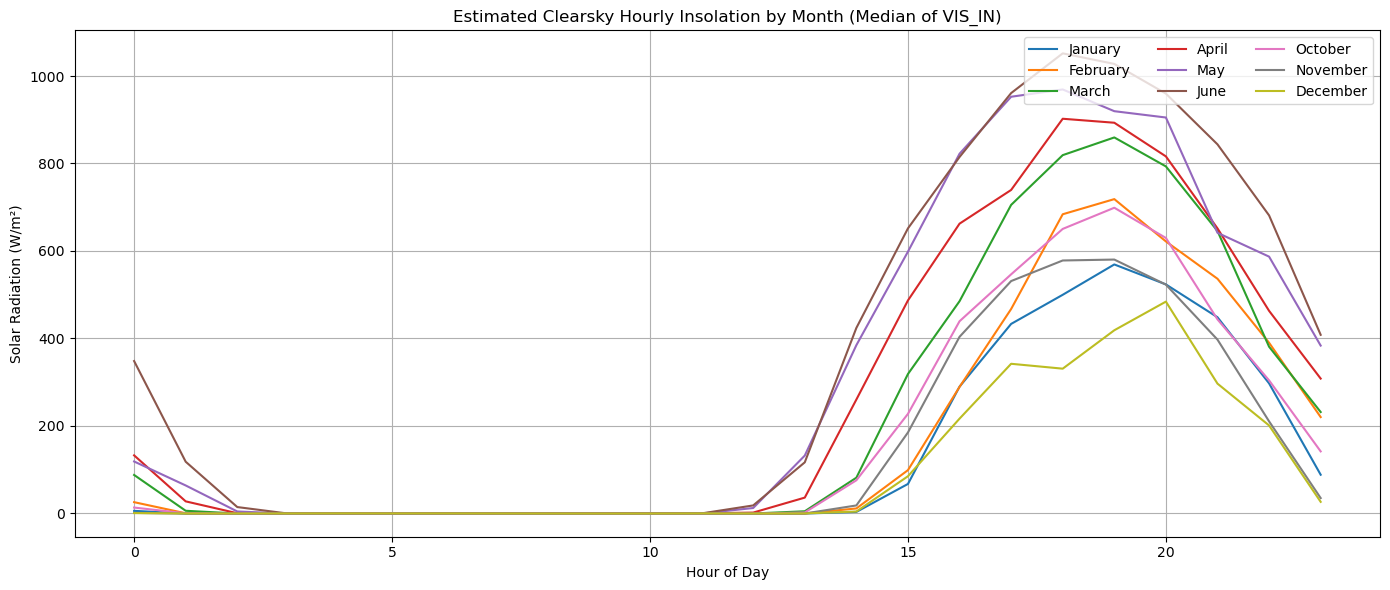

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure the index is a datetime
# Subset the DataFrame
irwin_pyra_hourly = irwin_pyra.resample('1h').mean()
# irwin_pyra_wy2022 = irwin_pyra_hourly.loc[start_wy2022 : end_wy2022]
irwin_pyra_hourly_wy2022 = irwin_pyra_hourly.loc['2021-10-01':'2022-06-25']

# Make sure the index of irwin_pyra is datetime
irwin_pyra_hourly_wy2022.index = pd.to_datetime(irwin_pyra_hourly_wy2022.index)

# Extract hour and month from the datetime index
irwin_pyra_hourly_wy2022['hour'] = irwin_pyra_hourly_wy2022.index.hour
irwin_pyra_hourly_wy2022['month'] = irwin_pyra_hourly_wy2022.index.month

# Group by month and hour, then calculate the median and mean VIS_IN
clearsky_median = irwin_pyra_hourly_wy2022.groupby(['month', 'hour'])['VIS_IN'].median().unstack()
# clearsky_median = irwin_pyra_hourly_wy2022.groupby(['month', 'hour'])['VIS_IN'].max().unstack()
# clearsky_mean   = irwin_pyra_hourly_wy2022.groupby(['month', 'hour'])['VIS_IN'].mean().unstack()

# Plotting the "clearsky" (median) insolation by hour for each month
plt.figure(figsize=(14, 6))
for month in range(1, 13):
    if month in clearsky_median.index:
        plt.plot(clearsky_median.columns, clearsky_median.loc[month], label=pd.to_datetime(f'{month}', format='%m').strftime('%B'))

plt.title('Estimated Clearsky Hourly Insolation by Month (Median of VIS_IN)')
plt.xlabel('Hour of Day')
plt.ylabel('Solar Radiation (W/m²)')
plt.legend(loc='upper right', ncol=3)
plt.grid(True)
plt.tight_layout()
plt.show()


In [90]:
m1_obs

<xarray.DataArray 'down_short_hemisp' (time: 3162)> Size: 13kB
array([ 20.002304,  59.259438, 118.5501  , ..., 626.9018  , 621.48834 ,
       506.7862  ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 25kB 2021-10-01 ... 2022-06-25T23:00:00
Attributes:
    long_name:            Downwelling shortwave hemispheric irradiance
    units:                W/m^2
    valid_min:            0.0
    valid_max:            1200.0
    resolution:           0.1
    ancillary_variables:  qc_down_short_hemisp
    standard_name:        downwelling_shortwave_flux_in_air

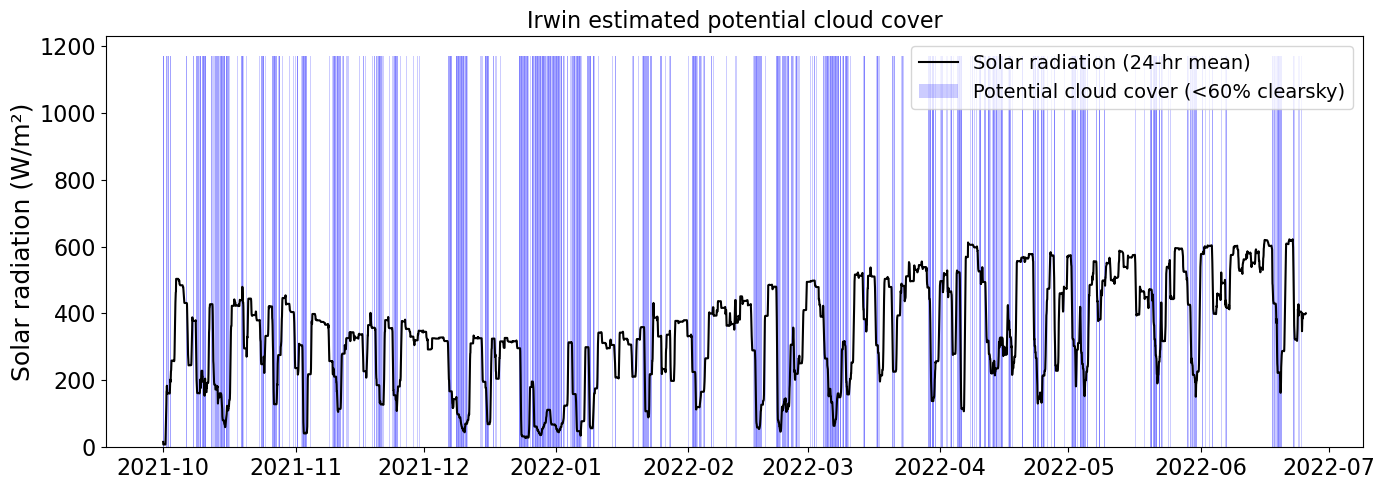

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime index and drop missing values
obs = irwin_pyra_hourly_wy2022[['VIS_IN']].copy()
obs.index = pd.to_datetime(obs.index)
obs.dropna(subset=['VIS_IN'], inplace=True)

# Extract month and hour for mapping to median clearsky
obs['month'] = obs.index.month
obs['hour'] = obs.index.hour

# Calculate clearsky (median) by month and hour
# clearsky_median = obs.groupby(['month', 'hour'])['VIS_IN'].median().unstack()
# clearsky_median = obs.groupby(['month', 'hour'])['VIS_IN'].max().unstack()

# Map the clearsky value to each row in the observed data
obs['clearsky_VIS_IN'] = obs.apply(lambda row: clearsky_median.loc[row['month'], row['hour']], axis=1)

# Compute ratio and flag storm hours (<60% of clearsky)
obs['ratio'] = obs['VIS_IN'] / obs['clearsky_VIS_IN']
obs['storm_hour'] = obs['ratio'] < 0.6

# Calculate 6-hour rolling mean (excluding 0s)
win = 24
rolling_mean = obs['VIS_IN'].where(obs['VIS_IN'] > 0).rolling(window=win, min_periods=1).mean()

# Plot storm hours and rolling mean
plt.figure(figsize=(14, 5))
plt.bar(obs.index, obs['storm_hour']*obs['VIS_IN'].max(), width=0.1, alpha=0.2, color='blue', label='Potential cloud cover (<60% clearsky)')
plt.plot(rolling_mean.index, rolling_mean, color='black', linewidth=1.5, label='Solar radiation (24-hr mean)')
plt.ylabel('Solar radiation (W/m²)', fontsize=18)
plt.tick_params(axis='both', labelsize=16)
plt.tick_params(axis='both', labelsize=16)
plt.title('Irwin estimated potential cloud cover', fontsize=16)
# plt.title('Irwin monthly mean bias with potential cloud cover', fontsize=14)
# plt.legend()
plt.legend(title='', fontsize=14)  # Adjust as needed
plt.tight_layout()
plt.show()
svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/topo-split-rmgsa/"
# plt.savefig(svpth + 'clouds-25hr-mean-60.png', dpi=300, bbox_inches='tight')


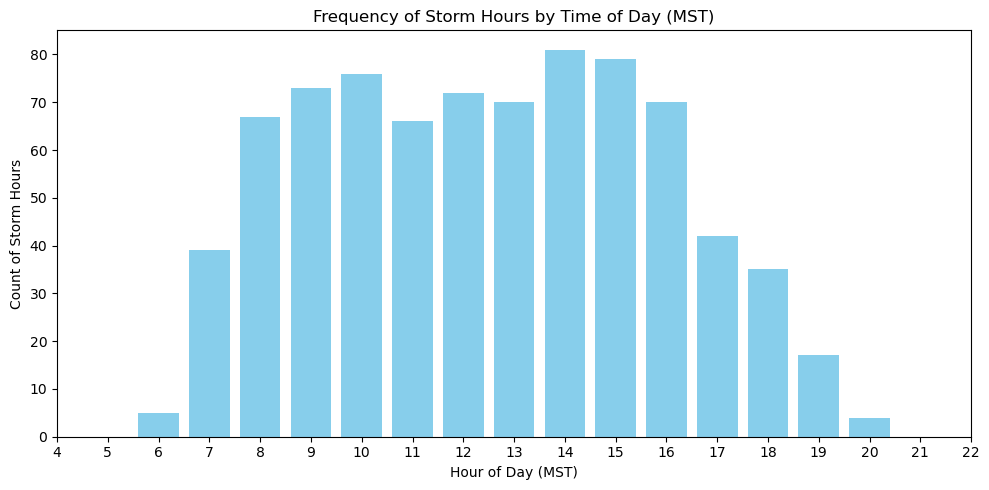

In [49]:
# Make a copy and ensure datetime
obs = irwin_pyra_hourly_wy2022[['VIS_IN']].copy()
obs.index = pd.to_datetime(obs.index)
obs.dropna(subset=['VIS_IN'], inplace=True)

# Convert to MST (UTC-7)
obs.index = obs.index.tz_localize('UTC').tz_convert('US/Mountain')
obs['hour_mst'] = obs.index.hour
obs['month'] = obs.index.month

# Compute median clearsky values by hour/month
clearsky_median = obs.groupby(['month', 'hour_mst'])['VIS_IN'].median().unstack()
obs['clearsky_VIS_IN'] = obs.apply(lambda row: clearsky_median.loc[row['month'], row['hour_mst']], axis=1)

# Only consider hours where clearsky is greater than a threshold (e.g., >10 W/m²)
obs['is_daylight'] = obs['clearsky_VIS_IN'] > 10

# Only compute ratio where daylight is present
obs_day = obs[obs['is_daylight']].copy()
obs_day['ratio'] = obs_day['VIS_IN'] / obs_day['clearsky_VIS_IN']
obs_day['storm_hour'] = obs_day['ratio'] < 0.6

# Count storm hours by time of day (MST)
storm_hour_counts = obs_day[obs_day['storm_hour']].groupby('hour_mst').size()

# Plot
plt.figure(figsize=(10, 5))
plt.bar(storm_hour_counts.index, storm_hour_counts.values, color='skyblue')
plt.xticks(range(4, 23))  # Typical daylight hours
plt.xlabel('Hour of Day (MST)')
plt.ylabel('Count of Storm Hours')
plt.title('Frequency of Storm Hours by Time of Day (MST)')
plt.tight_layout()
plt.show()

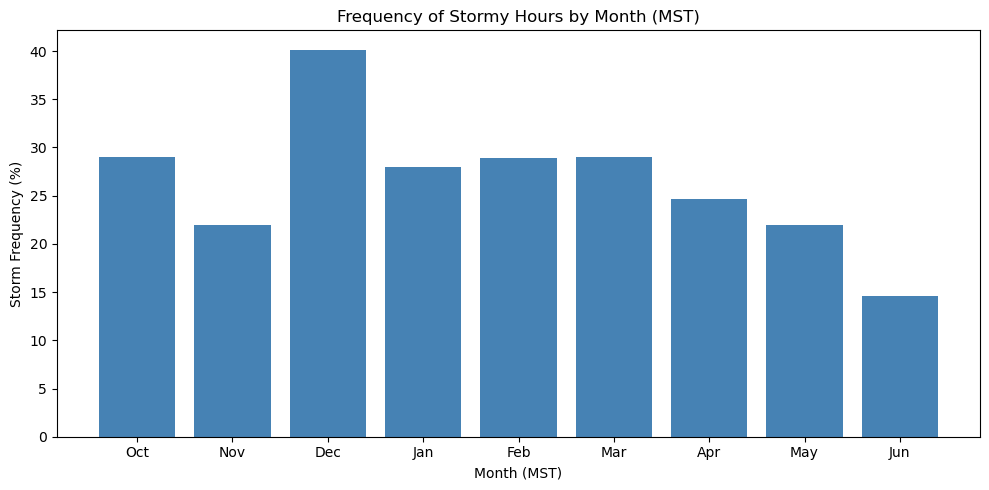

In [50]:


# Ensure datetime and convert to MST
obs = irwin_pyra_hourly_wy2022[['VIS_IN']].copy()
obs.index = pd.to_datetime(obs.index)
obs.dropna(subset=['VIS_IN'], inplace=True)
obs.index = obs.index.tz_localize('UTC').tz_convert('US/Mountain')

# Extract month and hour
obs['hour_mst'] = obs.index.hour
obs['month'] = obs.index.month

# Median clearsky values (per hour per month)
clearsky_median = obs.groupby(['month', 'hour_mst'])['VIS_IN'].median().unstack()

# Map clearsky expected value to each row
obs['clearsky_VIS_IN'] = obs.apply(lambda row: clearsky_median.loc[row['month'], row['hour_mst']], axis=1)

# Filter to daytime hours (clearsky VIS_IN > 10)
obs_daylight = obs[obs['clearsky_VIS_IN'] > 10].copy()

# Storm detection
obs_daylight['ratio'] = obs_daylight['VIS_IN'] / obs_daylight['clearsky_VIS_IN']
obs_daylight['storm_hour'] = obs_daylight['ratio'] < 0.6

# Count storm hours and total daylight hours per month
storm_counts = obs_daylight.groupby('month')['storm_hour'].sum()
daylight_counts = obs_daylight.groupby('month').size()
storm_freq = (storm_counts / daylight_counts) * 100

# Limit to water year: Oct (10) to Jun (6)
months_ordered = [10, 11, 12, 1, 2, 3, 4, 5, 6]
month_names = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
storm_freq = storm_freq.reindex(months_ordered)

# Plot
plt.figure(figsize=(10, 5))
plt.bar(month_names, storm_freq.values, color='steelblue')
plt.ylabel('Storm Frequency (%)')
plt.xlabel('Month (MST)')
plt.title('Frequency of Stormy Hours by Month (MST)')
plt.tight_layout()
plt.show()


In [46]:
irwin_dsw3

<xarray.Dataset> Size: 88kB
Dimensions:  (time: 7320)
Coordinates:
    x        float32 4B ...
    y        float32 4B ...
  * time     (time) datetime64[ns] 59kB 2021-09-30T06:00:00 ... 2022-08-01T05...
Data variables:
    dsw3h    (time) float32 29kB 0.0 0.0 0.0 0.0 0.0 ... 116.3 18.83 0.0 0.0 0.0

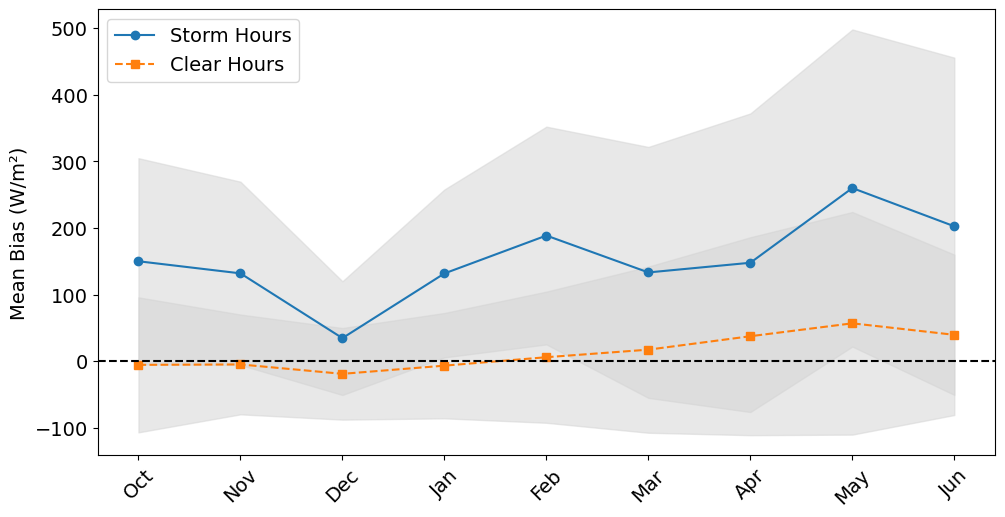

In [53]:

bias = irwin_bias_mst

# Attach bias and storm info
analysis_df = pd.DataFrame({
    'bias': bias,
    'storm': obs_daylight['storm_hour'],
    'month': obs_daylight['month'],
    'hour': obs_daylight['hour_mst']
})

# Define RMSE function
def rmse(x):
    return np.sqrt(np.mean(x**2))

# Group by month and storm status
monthly_stats = analysis_df.groupby(['month', 'storm'])['bias'].agg(['mean', 'std', rmse]).reset_index()

# Map the month numbers to month names
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
monthly_stats['Month'] = monthly_stats['month'].map(month_map)

# Filter out September
monthly_stats = monthly_stats[monthly_stats['month'] != 9]

# Manually reorder months to go from Oct to Jun
month_order = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
monthly_stats['Month'] = pd.Categorical(monthly_stats['Month'], categories=month_order, ordered=True)

# Sort the DataFrame by the month order
monthly_stats = monthly_stats.sort_values(by='Month')

# Assign 'Condition' as 'Storm' or 'Clear'
monthly_stats['Condition'] = np.where(monthly_stats['storm'], 'Storm', 'Clear')

# Plot Mean Bias with Standard Deviation
plt.figure(figsize=(10, 5))
for cond, style in zip(['Storm', 'Clear'], ['o-', 's--']):
    subset = monthly_stats[monthly_stats['Condition'] == cond]
    plt.plot(subset['Month'], subset['mean'], style, label=f'{cond} Hours')
    # Add standard deviation as shaded area around the mean
    plt.fill_between(subset['Month'], subset['mean'] - subset['std'], subset['mean'] + subset['std'], 
                     color='lightgrey', alpha=0.5)

plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Mean Bias (W/m²)', fontsize=14)
# plt.title('Irwin monthly mean bias with potential cloud cover', fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.xticks(rotation=45, fontsize=14)  # Rotate x-axis labels for better readability
plt.yticks(fontsize=14)
# plt.set_title("HRRR-TopoSplit - ASO", fontsize=14)
# plt.set_ylabel("Mean Bias (W/m²)", fontsize=14)
# plt.set_xlabel("", fontsize=14)
plt.show()
svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/topo-split-rmgsa/"
# plt.savefig(svpth + 'clouds-seasonal-mean.png', dpi=300, bbox_inches='tight')


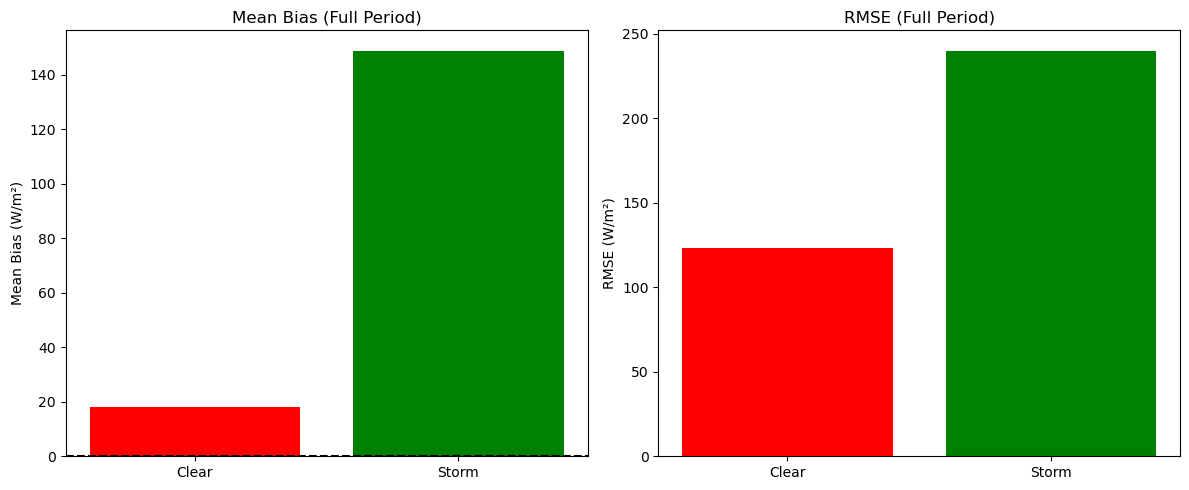

,storm,mean,rmse,Condition
0,False,18.203056,123.321386,Clear
1,True,148.886008,240.094826,Storm


In [54]:


bias = irwin_bias_mst

# Attach bias and storm info
analysis_df = pd.DataFrame({
    'bias': bias,
    'storm': obs_daylight['storm_hour'],
    'month': obs_daylight['month'],
    'hour': obs_daylight['hour_mst']
})

# Define RMSE function
def rmse(x):
    return np.sqrt(np.mean(x**2))

# Group by month and storm status
monthly_stats = analysis_df.groupby(['month', 'storm'])['bias'].agg(['mean', rmse]).reset_index()

# Map the month numbers to month names
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
monthly_stats['Month'] = monthly_stats['month'].map(month_map)

# Filter out September
monthly_stats = monthly_stats[monthly_stats['month'] != 9]

# Manually reorder months to go from Oct to Jun
month_order = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
monthly_stats['Month'] = pd.Categorical(monthly_stats['Month'], categories=month_order, ordered=True)

# Sort the DataFrame by the month order
monthly_stats = monthly_stats.sort_values(by='Month')

# Assign 'Condition' as 'Storm' or 'Clear'
monthly_stats['Condition'] = np.where(monthly_stats['storm'], 'Storm', 'Clear')

# Overall stats for storm vs clear
overall_stats = analysis_df.groupby('storm')['bias'].agg(['mean', rmse]).reset_index()
overall_stats['Condition'] = np.where(overall_stats['storm'], 'Storm', 'Clear')

# Bar plot for full-period mean bias and RMSE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(overall_stats['Condition'], overall_stats['mean'], color=['red', 'green'])
axes[0].set_title('Mean Bias (Full Period)')
axes[0].set_ylabel('Mean Bias (W/m²)')
axes[0].axhline(0, color='black', linestyle='--')

axes[1].bar(overall_stats['Condition'], overall_stats['rmse'], color=['red', 'green'])
axes[1].set_title('RMSE (Full Period)')
axes[1].set_ylabel('RMSE (W/m²)')

plt.tight_layout()
plt.show()

overall_stats

In [79]:
obs_daylight
irwin_bias_mst
bias
obs_daylight
# analysis_df

,VIS_IN,hour_mst,month,clearsky_VIS_IN,ratio,storm_hour
2021-09-30 18:00:00,16.068948,18,9,16.068948,1.000000,False
2021-10-01 08:00:00,101.016263,8,10,74.936795,1.348020,False
2021-10-01 09:00:00,153.599700,9,10,226.951825,0.676794,False
2021-10-01 10:00:00,181.178250,10,10,438.884200,0.412816,True
2021-10-01 11:00:00,260.409600,11,10,546.280375,0.476696,True
...,...,...,...,...,...,...
2022-06-24 19:00:00,160.034433,19,6,116.656854,1.371839,False
2022-06-24 20:00:00,11.218835,20,6,13.081934,0.857582,False
2022-06-25 06:00:00,15.074525,6,6,17.382754,0.867212,False
2022-06-25 07:00:00,103.789322,7,6,116.026770,0.894529,False


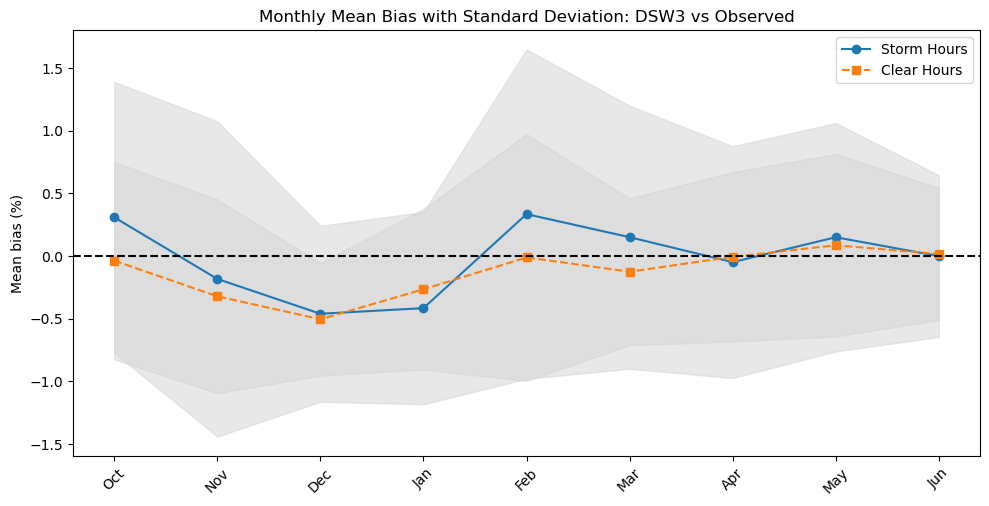

In [84]:

# use relative bias
epsilon = 1e-6
bias = ((irwin_model_df - irwin_obs) / (irwin_obs + epsilon)).dropna()
# bias = ((irwin_model_df - irwin_obs) / irwin_model_df).dropna()
bias.index = bias.index.tz_localize(None)
obs_daylight.index = obs_daylight.index.tz_localize(None)
# bias = irwin_bias_mst

# Attach bias and storm info
analysis_df = pd.DataFrame({
    'bias': bias,
    'storm': obs_daylight['storm_hour'],
    'month': obs_daylight['month'],
    'hour': obs_daylight['hour_mst']
})

# Define RMSE function
def rmse(x):
    return np.sqrt(np.mean(x**2))

# Group by month and storm status
monthly_stats = analysis_df.groupby(['month', 'storm'])['bias'].agg(['mean', 'std', rmse]).reset_index()

# Map the month numbers to month names
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
monthly_stats['Month'] = monthly_stats['month'].map(month_map)

# Filter out September
monthly_stats = monthly_stats[monthly_stats['month'] != 9]

# Manually reorder months to go from Oct to Jun
month_order = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
monthly_stats['Month'] = pd.Categorical(monthly_stats['Month'], categories=month_order, ordered=True)

# Sort the DataFrame by the month order
monthly_stats = monthly_stats.sort_values(by='Month')

# Assign 'Condition' as 'Storm' or 'Clear'
monthly_stats['Condition'] = np.where(monthly_stats['storm'], 'Storm', 'Clear')

# Plot Mean Bias with Standard Deviation
plt.figure(figsize=(10, 5))
for cond, style in zip(['Storm', 'Clear'], ['o-', 's--']):
    subset = monthly_stats[monthly_stats['Condition'] == cond]
    plt.plot(subset['Month'], subset['mean'], style, label=f'{cond} Hours')
    # Add standard deviation as shaded area around the mean
    plt.fill_between(subset['Month'], subset['mean'] - subset['std'], subset['mean'] + subset['std'], 
                     color='lightgrey', alpha=0.5)

plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Mean bias (%)')
plt.title('Monthly Mean Bias with Standard Deviation: DSW3 vs Observed')
plt.legend()
plt.tight_layout()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()


In [121]:

def calculate_storm_hours(xr_dataarray, site_name='Site'):
    # Convert to Pandas Series
    obs = xr_dataarray.to_series()
    obs = obs[obs > 0]  # Remove nighttime or bad values

    # Ensure datetime index
    obs.index = pd.to_datetime(obs.index)

    # Create DataFrame
    obs_df = pd.DataFrame({'VIS_IN': obs})
    obs_df['month'] = obs_df.index.month
    obs_df['hour'] = obs_df.index.hour

    # Calculate clearsky median by month & hour
    clearsky_median = obs_df.groupby(['month', 'hour'])['VIS_IN'].median().unstack()

    # Map expected clearsky to each row
    obs_df['clearsky_VIS_IN'] = obs_df.apply(
        lambda row: clearsky_median.loc[row['month'], row['hour']], axis=1
    )

    # Compute ratio and storm flag
    obs_df['ratio'] = obs_df['VIS_IN'] / obs_df['clearsky_VIS_IN']
    obs_df['storm_hour'] = obs_df['ratio'] < 0.9

    # Optional: Rolling 6-hour mean (excluding 0s)
    win = 6
    obs_df['rolling_mean'] = obs_df['VIS_IN'].rolling(window=win, min_periods=1).mean()

    # Optional: Plot (customizable per site)
    plt.figure(figsize=(14, 5))
    plt.bar(obs_df.index, obs_df['storm_hour'] * obs_df['VIS_IN'].max(), width=0.1,
            alpha=0.2, color='blue', label='Storm hours (<60% clearsky)')
    plt.plot(obs_df.index, obs_df['rolling_mean'], color='black', linewidth=1.5, label='6-hr rolling mean')
    plt.ylabel('Solar radiation (W/m²)', fontsize=14)
    plt.title(f'Storm Hour Detection – {site_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return obs_df


def compute_monthly_bias_stats(bias, obs_metadata, site_name='Site'):
    # Ensure timezone-naive for join
    bias.index = bias.index.tz_localize(None)
    obs_metadata.index = obs_metadata.index.tz_localize(None)
    
    # Align times (keep only common timestamps)
    common_idx = bias.index.intersection(obs_metadata.index)
    bias = bias.loc[common_idx]
    obs_metadata = obs_metadata.loc[common_idx]

    # Build analysis DataFrame
    analysis_df = pd.DataFrame({
        'bias': bias,
        'storm': obs_metadata['storm_hour'],
        'month': obs_metadata['month'],
        'hour': obs_metadata['hour']
    })

    # Define RMSE
    def rmse(x):
        return np.sqrt(np.mean(x**2))

    # Group stats by month and storm status
    monthly_stats = analysis_df.groupby(['month', 'storm'])['bias'].agg(['mean', 'std', rmse]).reset_index()

    # Map month numbers to names
    month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
                 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
    monthly_stats['Month'] = monthly_stats['month'].map(month_map)

    # Filter and reorder
    monthly_stats = monthly_stats[monthly_stats['month'] != 9]
    month_order = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
    monthly_stats['Month'] = pd.Categorical(monthly_stats['Month'], categories=month_order, ordered=True)
    monthly_stats = monthly_stats.sort_values(by='Month')

    # Label condition
    monthly_stats['Condition'] = np.where(monthly_stats['storm'], 'Storm', 'Clear')

    return monthly_stats


def plot_monthly_bias(monthly_stats, site_name='Site'):
    plt.figure(figsize=(10, 5))
    for cond, style in zip(['Storm', 'Clear'], ['o-', 's--']):
        subset = monthly_stats[monthly_stats['Condition'] == cond]
        plt.plot(subset['Month'], subset['mean'], style, label=f'{cond} Hours')
        plt.fill_between(subset['Month'],
                         subset['mean'] - subset['std'],
                         subset['mean'] + subset['std'],
                         color='lightgrey', alpha=0.5)
    
    plt.axhline(0, color='black', linestyle='--')
    plt.ylabel('Mean Bias (W/m²)')
    plt.title(f'Monthly Mean Bias with Std: {site_name} (DSW3 vs Observed)')
    plt.legend()
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()


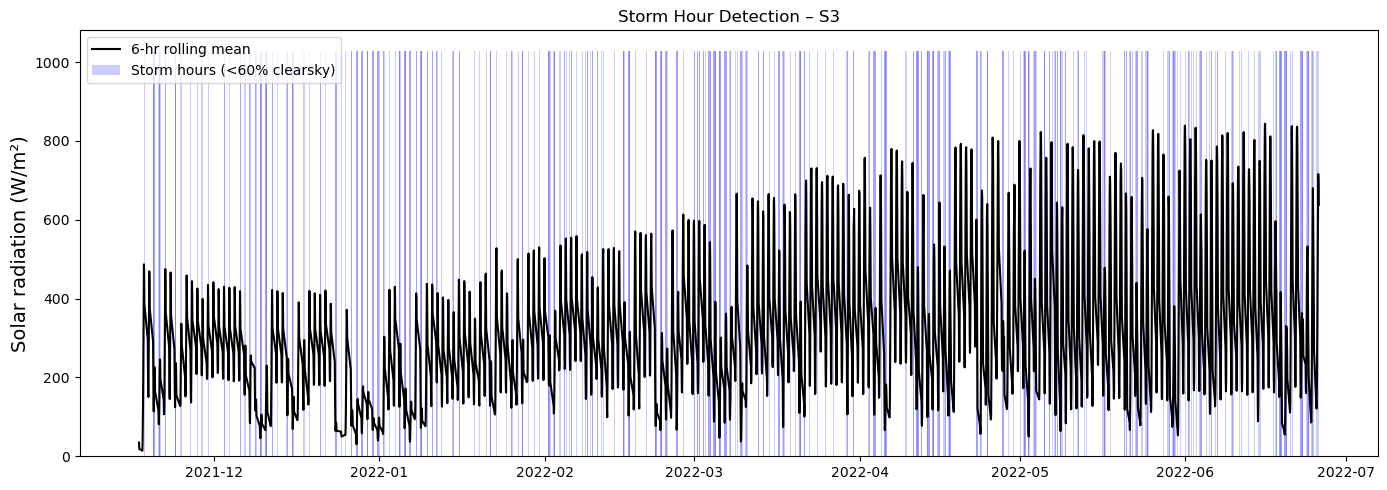

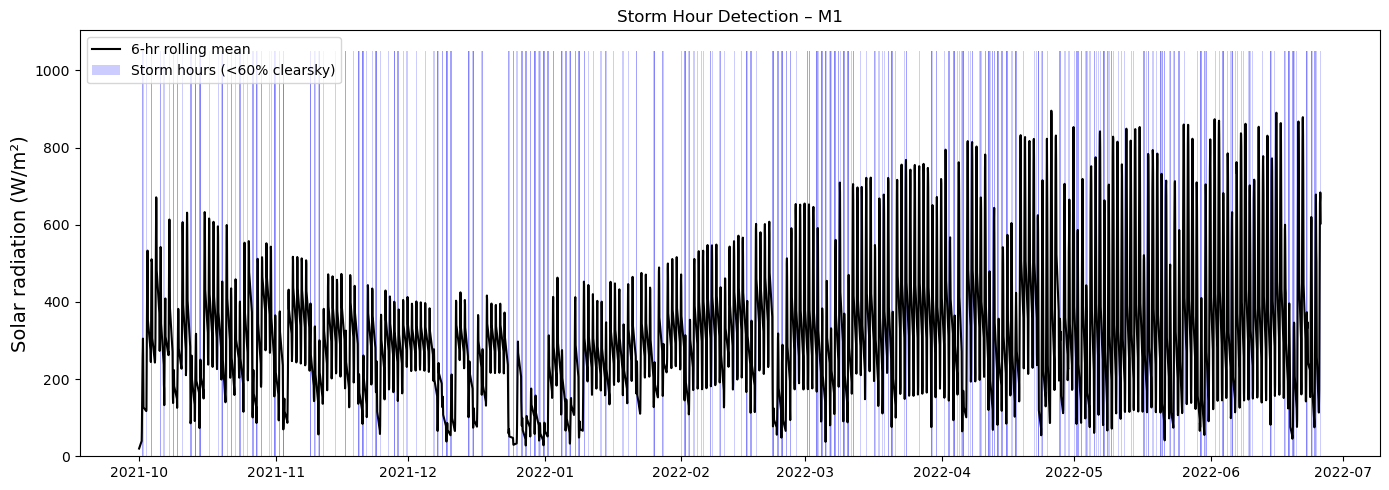

In [122]:
s3_daylight = calculate_storm_hours(s3_obs, site_name='S3')
m1_daylight = calculate_storm_hours(m1_obs, site_name='M1')


In [116]:
# S3 Observed Data
s3_obs = s3_sail['down_short_hemisp'].sel(time=slice(start_wy2022, end_wy2022)).clip(min=0).resample(time='1h').mean()
s3_obs = s3_obs[s3_obs > 0]  # Filter out non-positive values

# Convert the xarray time dimension to pandas DatetimeIndex
s3_obs_time = s3_obs.time.to_index()

# Convert to datetime and localize to UTC, then convert to Mountain Time
s3_obs_time = s3_obs_time.tz_localize('UTC').tz_convert('US/Mountain')

# Now, create a pandas DataFrame from the xarray DataArray to easily manipulate
s3_obs_df = s3_obs.to_dataframe()

# Add time-related columns (hour and month)
s3_obs_df['hour_mst'] = s3_obs_time.hour
s3_obs_df['month'] = s3_obs_time.month

# Clearsky calculation by month and hour (median value for each)
clearsky_median_s3 = s3_obs_df.groupby(['month', 'hour_mst'])['down_short_hemisp'].median().unstack()

# Map the clearsky value to each row in the observed data
s3_obs_df['clearsky_VIS_IN'] = s3_obs_df.apply(lambda row: clearsky_median_s3.loc[row['month'], row['hour_mst']], axis=1)

# Compute ratio and flag storm hours (<60% of clearsky)
s3_obs_df['ratio'] = s3_obs_df['down_short_hemisp'] / s3_obs_df['clearsky_VIS_IN']
s3_obs_df['storm_hour'] = s3_obs_df['ratio'] < 0.6

# Rolling mean (6-hour window) for visualization
s3_obs_df['rolling_mean'] = s3_obs_df['down_short_hemisp'].where(s3_obs_df['down_short_hemisp'] > 0).rolling(window=6, min_periods=1).mean()


In [117]:
# M1 Observed Data
m1_obs = m1_sail['down_short_hemisp'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
m1_obs = m1_obs[m1_obs > 0]  # Filter out non-positive values

# Convert the xarray time dimension to pandas DatetimeIndex
m1_obs_time = m1_obs.time.to_index()

# Convert to datetime and localize to UTC, then convert to Mountain Time
m1_obs_time = m1_obs_time.tz_localize('UTC').tz_convert('US/Mountain')

# Now, create a pandas DataFrame from the xarray DataArray to easily manipulate
m1_obs_df = m1_obs.to_dataframe()

# Add time-related columns (hour and month)
m1_obs_df['hour_mst'] = m1_obs_time.hour
m1_obs_df['month'] = m1_obs_time.month

# Clearsky calculation by month and hour (median value for each)
clearsky_median_m1 = m1_obs_df.groupby(['month', 'hour_mst'])['down_short_hemisp'].median().unstack()

# Map the clearsky value to each row in the observed data
m1_obs_df['clearsky_VIS_IN'] = m1_obs_df.apply(lambda row: clearsky_median_m1.loc[row['month'], row['hour_mst']], axis=1)

# Compute ratio and flag storm hours (<60% of clearsky)
m1_obs_df['ratio'] = m1_obs_df['down_short_hemisp'] / m1_obs_df['clearsky_VIS_IN']
m1_obs_df['storm_hour'] = m1_obs_df['ratio'] < 0.6

# Rolling mean (6-hour window) for visualization
m1_obs_df['rolling_mean'] = m1_obs_df['down_short_hemisp'].where(m1_obs_df['down_short_hemisp'] > 0).rolling(window=6, min_periods=1).mean()


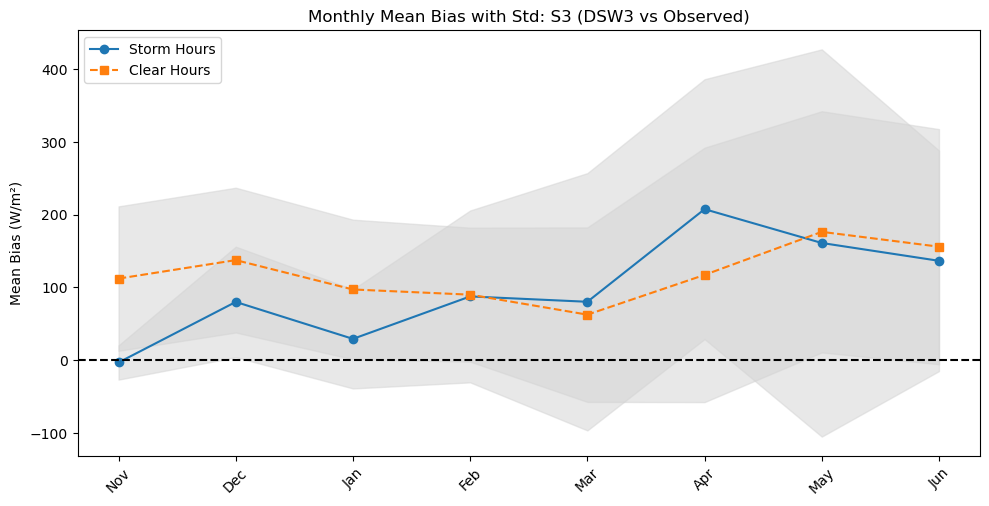

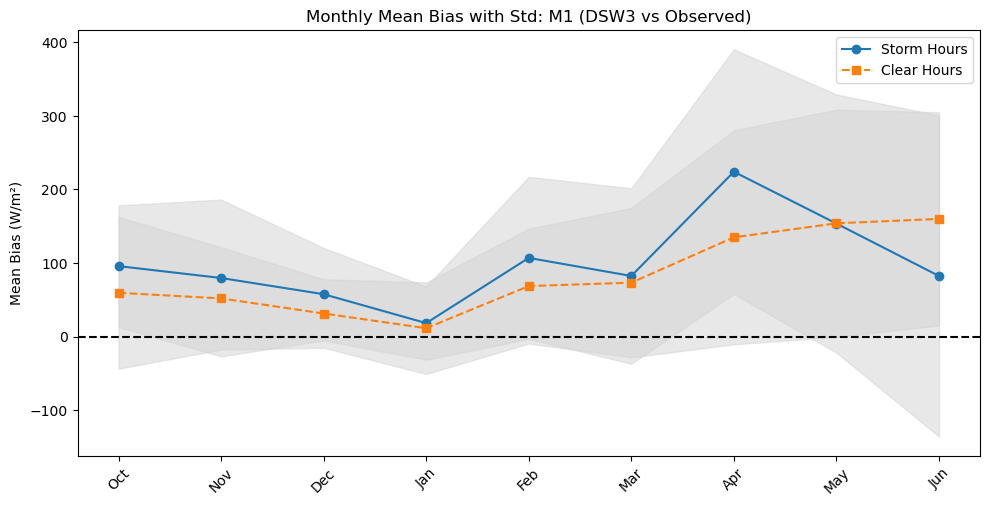

In [118]:
# Generate monthly stats and plots


s3_stats = compute_monthly_bias_stats(s3_bias, s3_daylight, site_name='S3')
plot_monthly_bias(s3_stats, site_name='S3')

m1_stats = compute_monthly_bias_stats(m1_bias, m1_daylight, site_name='M1')
plot_monthly_bias(m1_stats, site_name='M1')


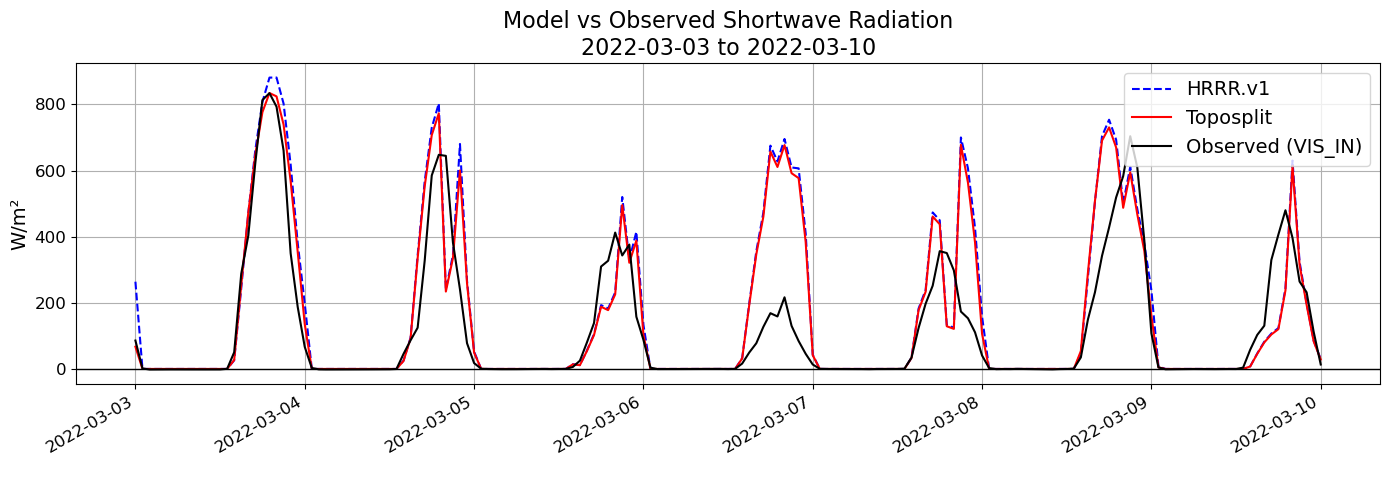

In [69]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import timedelta

# === 1. Set date range ===
# start_date = pd.to_datetime('2022-01-20').tz_localize('UTC')
start_date = pd.to_datetime('2022-03-03').tz_localize('UTC')
end_date = start_date + timedelta(days=7)

# Convert to tz-naive for slicing
start_naive = start_date.tz_convert(None)
end_naive = end_date.tz_convert(None)

# === 2. Subset observed data ===
if irwin_pyra_hourly.index.tz is not None:
    irwin_pyra_hourly.index = irwin_pyra_hourly.index.tz_convert(None)

idf_subset = irwin_pyra_hourly.loc[start_naive:end_naive]

# === 3. Subset model data ===
win = 1
dsw1_rolling = irwin_dsw1['dsw1'].rolling(time=win, center=True).mean()
dsw3_rolling = irwin_dsw3['dsw3h'].rolling(time=win, center=True).mean()

dsw1_subset = dsw1_rolling.sel(time=slice(start_naive, end_naive)).squeeze().to_series()
dsw3_subset = dsw3_rolling.sel(time=slice(start_naive, end_naive)).squeeze().to_series()

# === 4. Plot ===
fig, ax = plt.subplots(figsize=(14, 5))

# Plot models
ax.plot(dsw1_subset.index, dsw1_subset.values, label='HRRR.v1', color='blue', linestyle='--')
ax.plot(dsw3_subset.index, dsw3_subset.values, label='Toposplit', color='red')

# Plot observation
ax.plot(idf_subset.index, idf_subset['VIS_IN'], label='Observed (VIS_IN)', color='black')

# Styling
ax.axhline(0, color='black', linewidth=1)
ax.set_title(f'Model vs Observed Shortwave Radiation\n{start_date.date()} to {end_date.date()}', fontsize=16)
# ax.set_ylabel('W/m²', fontsize=14)
ax.legend(fontsize=14)
ax.set_xlabel(' ', fontsize=14)         # X-axis label
ax.set_ylabel('W/m²', fontsize=14)         # Y-axis label
ax.tick_params(axis='both', labelsize=12)  # Tick labels (both axes)
ax.grid(True)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/topo-split-rmgsa/"
# plt.savefig(svpth + 'weekly-plot-march03.png', dpi=300, bbox_inches='tight')
